<a href="https://colab.research.google.com/github/Nkengfack/Bank_marketing_ml_Classifications/blob/main/bank_marketing_ML_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Comparative Performance Analysis of Machine Learning Models for the Prediction of Bank Term Deposit Subscriptions

## Research question

Which machine learning classifier, among LightGBM, XGBoost, Random Forest and Logistic Regression, most accurately predicts whether a bank client will subscribe to a term deposit following a telemarketing campaign, when evaluated on a class-imbalanced dataset using F1-score as the primary metric?

## Objectives

1. Perform exploratory data analysis to understand feature distributions, categorical conversion rates and the extent of class imbalance.
2. Engineer features that resolve known data quirks and construct a leakage-safe preprocessing pipeline with SMOTE resampling of the training folds.
3. Train and evaluate the four classifiers with default parameters, then optimise each with RandomizedSearchCV scored on F1, recording the trials and best parameters found.
4. Compare baseline and tuned models on accuracy, precision, recall, F1-score, ROC-AUC and average precision, with confusion matrices, ROC curves and precision-recall curves.
5. Interpret every tuned model through feature importance, quantify the uncertainty in the model ranking, and evaluate the best model once on a held-out test set.

## Dataset provenance

The data originates from the UCI Machine Learning Repository's Bank Marketing dataset, collected by a Portuguese retail bank from its direct telemarketing campaigns between May 2008 and November 2010, and first published by Moro, Cortez and Rita (2014). Each row is one phone contact with a client. The columns record client demographics, campaign contact history and macro-economic indicators at the time of the call. The bank collected the data to evaluate and improve the targeting of its term deposit campaigns.

Reference: Moro, S., Cortez, P. and Rita, P., (2014), 'A data-driven approach to predict the success of bank telemarketing', *Decision Support Systems*, 62, pp. 22-31.

## Ethical considerations

The dataset is anonymised, with no names, account numbers or other direct identifiers, and it was publicly released for research by its original authors. Three issues were still considered. The data describes real individuals contacted without any prospect of consent for secondary research, which is mitigated by the anonymisation and by the aggregate nature of this analysis. Models trained on demographic attributes such as age, job and marital status could, if deployed, systematically exclude some groups from financial products, so any deployment would require a fairness audit of those attributes. The macro-economic features tie the data to the 2008 to 2010 financial crisis in Portugal, so conclusions should not be generalised to other periods or markets without revalidation.

## Design choices

1. `duration` is dropped by default. Call duration is only known after the call ends, so it leaks the outcome and cannot inform the decision of who to call. Set `DROP_DURATION = False` to keep it.
2. The train, validation and test split happens before any fitting. Scaling and encoding live inside the pipeline, so nothing is learned from validation or test rows.

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve, average_precision_score)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Suppress only the specific expected warnings rather than silencing everything,
# so that genuine problems still surface during development.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_style('white')
RANDOM_STATE = 42
DROP_DURATION = True  # duration leaks the target; set to False to keep it

## 2. Load the data

In [3]:
FILE_URL = 'https://raw.githubusercontent.com/Nkengfack/Bank_marketing_ml_Classifications/refs/heads/main/bank_marketing_dataset.csv'

marketing = pd.read_csv(FILE_URL, sep=';')

# Replace dots in column names
marketing.columns = marketing.columns.str.replace('.', '_', regex=False)

# Readable labels for plot titles
feature_labels = {
    'age': 'Age',
    'job': 'Job',
    'marital': 'Marital Status',
    'education': 'Education',
    'default': 'Credit in Default',
    'housing': 'Housing Loan',
    'loan': 'Personal Loan',
    'contact': 'Contact Type',
    'month': 'Last Contact Month',
    'day_of_week': 'Last Contact Day',
    'duration': 'Call Duration (s)',
    'campaign': 'Contacts This Campaign',
    'pdays': 'Days Since Last Contact',
    'previous': 'Previous Contacts',
    'poutcome': 'Previous Outcome',
    'emp_var_rate': 'Employment Variation Rate',
    'cons_price_idx': 'Consumer Price Index',
    'cons_conf_idx': 'Consumer Confidence Index',
    'euribor3m': 'Euribor 3-Month Rate',
    'nr_employed': 'Number of Employees',
    'y': 'Subscribed'
}

marketing.sample(10, random_state=RANDOM_STATE)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
32884,57,technician,married,high.school,no,no,yes,cellular,may,mon,...,1,999,1,failure,-1.8,92.893,-46.2,1.299,5099.1,no
3169,55,unknown,married,unknown,unknown,yes,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no
32206,33,blue-collar,married,basic.9y,no,no,no,cellular,may,fri,...,1,999,1,failure,-1.8,92.893,-46.2,1.313,5099.1,no
9403,36,admin.,married,high.school,no,no,no,telephone,jun,fri,...,4,999,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1,no
14020,27,housemaid,married,high.school,no,yes,no,cellular,jul,fri,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no
17201,58,retired,married,professional.course,no,yes,yes,cellular,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
879,48,services,married,high.school,unknown,yes,no,telephone,may,wed,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
23757,51,admin.,divorced,university.degree,unknown,yes,no,cellular,aug,thu,...,7,999,0,nonexistent,1.4,93.444,-36.1,4.962,5228.1,no
10821,24,entrepreneur,married,university.degree,no,yes,yes,telephone,jun,wed,...,4,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
14355,36,technician,divorced,professional.course,no,yes,yes,cellular,jul,mon,...,4,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no


In [4]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [5]:
marketing.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp_var_rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons_price_idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons_conf_idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr_employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


## 3. Cleaning

In [6]:
duplicates = marketing.duplicated().sum()
marketing.drop_duplicates(keep='first', ignore_index=True, inplace=True)

print(f'Duplicate rows removed: {duplicates}')
print(f'Rows remaining: {len(marketing):,}')

Duplicate rows removed: 12
Rows remaining: 41,176


In [7]:
# No NaN values in this dataset, but several categoricals use the string 'unknown'
print('NaN values per column:')
print(marketing.isnull().sum().sum(), 'in total\n')

unknown_counts = (marketing == 'unknown').sum()
print("Rows with the value 'unknown':")
print(unknown_counts[unknown_counts > 0])
print(f"\n{unknown_counts.sum():,} in total")

NaN values per column:
0 in total

Rows with the value 'unknown':
job           330
marital        80
education    1730
default      8596
housing       990
loan          990
dtype: int64

12,716 in total


`unknown` is kept as its own category rather than imputed away. The absence of information (for example a client refusing to state their job) can itself be predictive, and one-hot encoding handles it without any guesswork.

In [8]:
numerical_cols = marketing.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = marketing.select_dtypes(include='object').drop(columns='y').columns.tolist()

for col in categorical_cols:
    print(f'{col}: {sorted(marketing[col].unique())}')

job: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
marital: ['divorced', 'married', 'single', 'unknown']
education: ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']
default: ['no', 'unknown', 'yes']
housing: ['no', 'unknown', 'yes']
loan: ['no', 'unknown', 'yes']
contact: ['cellular', 'telephone']
month: ['apr', 'aug', 'dec', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
day_of_week: ['fri', 'mon', 'thu', 'tue', 'wed']
poutcome: ['failure', 'nonexistent', 'success']


## 4. Exploratory data analysis

### 4.1 Target distribution and class imbalance

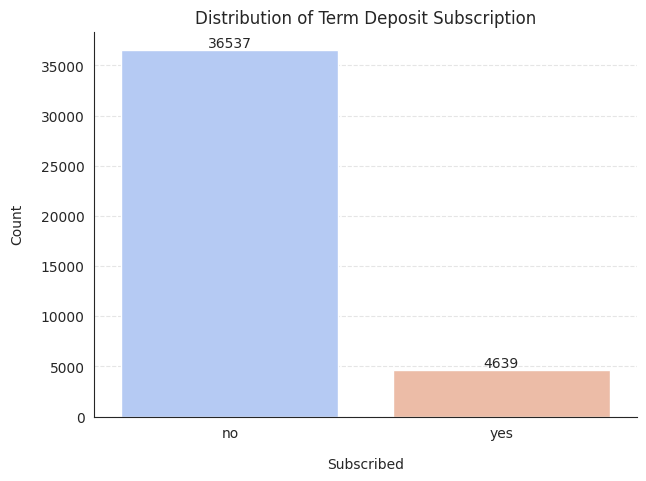

y
no     0.887
yes    0.113
Name: proportion, dtype: float64

Imbalance ratio (no : yes) = 7.9 : 1


In [9]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
sns.countplot(data=marketing, x='y', hue='y', palette='coolwarm', legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.title('Distribution of Term Deposit Subscription')
plt.xlabel('Subscribed', labelpad=12)
plt.ylabel('Count', labelpad=12)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

class_share = marketing['y'].value_counts(normalize=True).round(3)
ratio = marketing['y'].value_counts()
print(class_share)
print(f"\nImbalance ratio (no : yes) = {ratio['no'] / ratio['yes']:.1f} : 1")


### 4.2 Numerical distributions

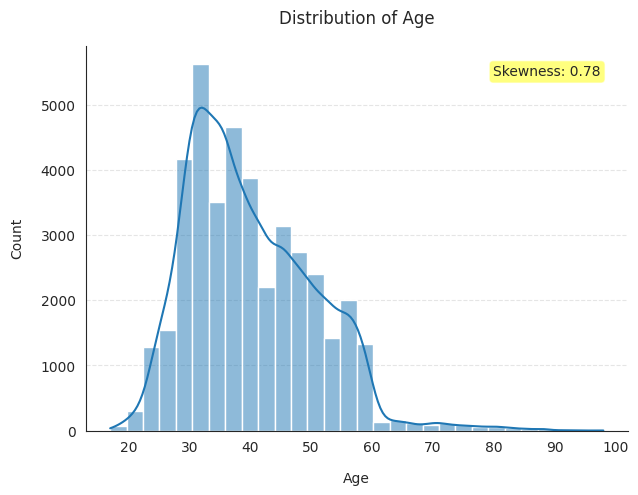

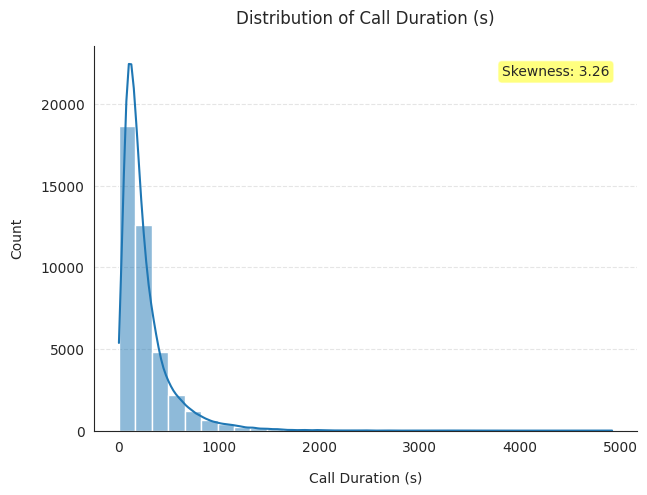

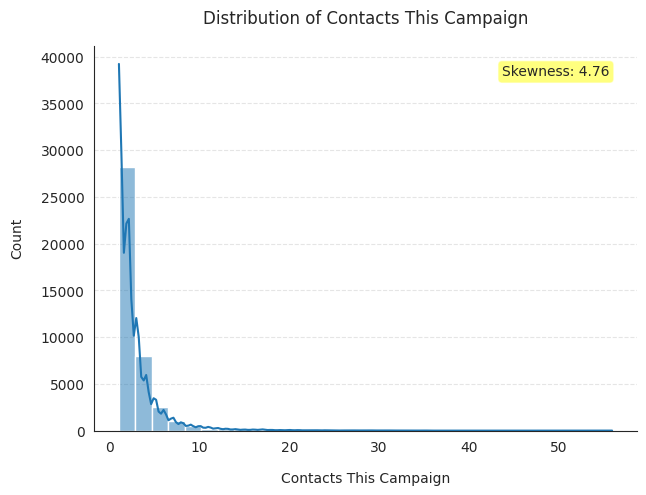

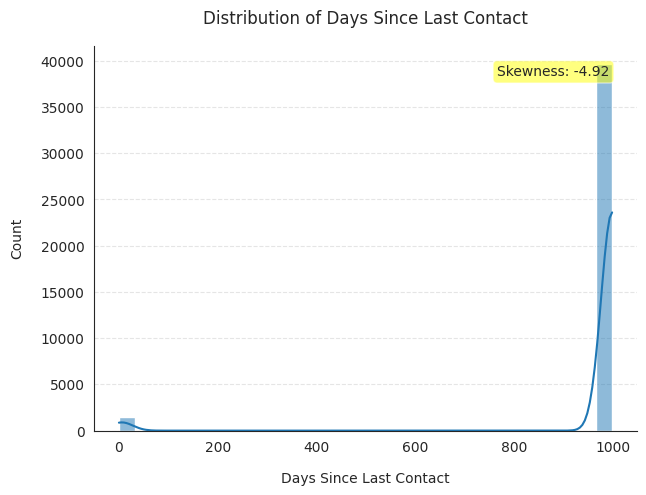

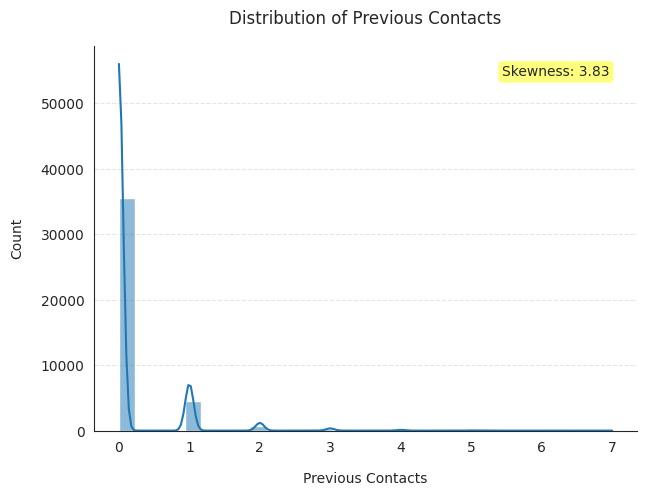

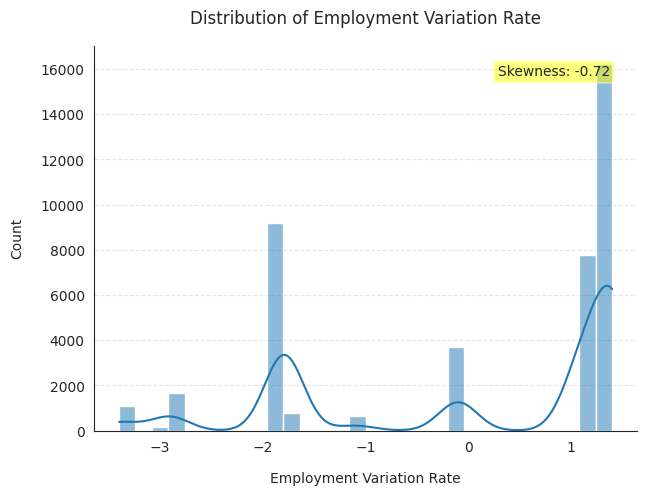

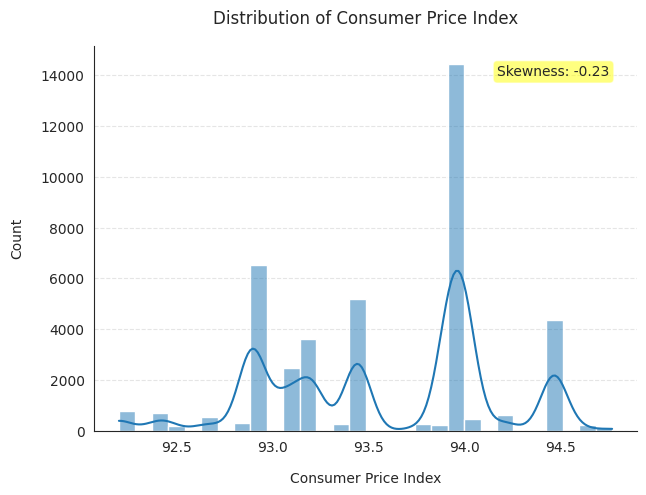

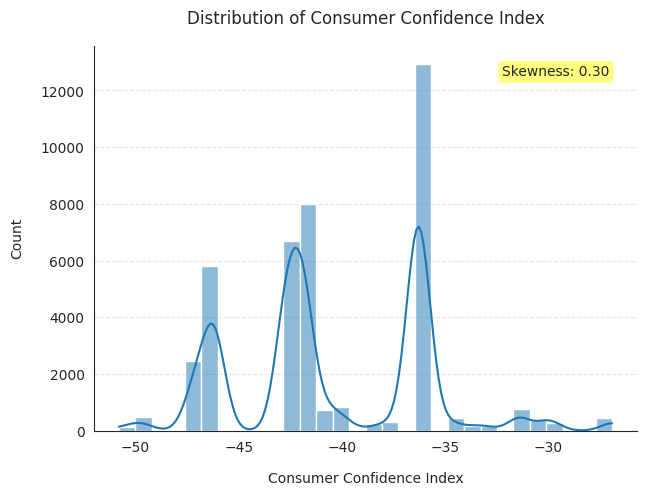

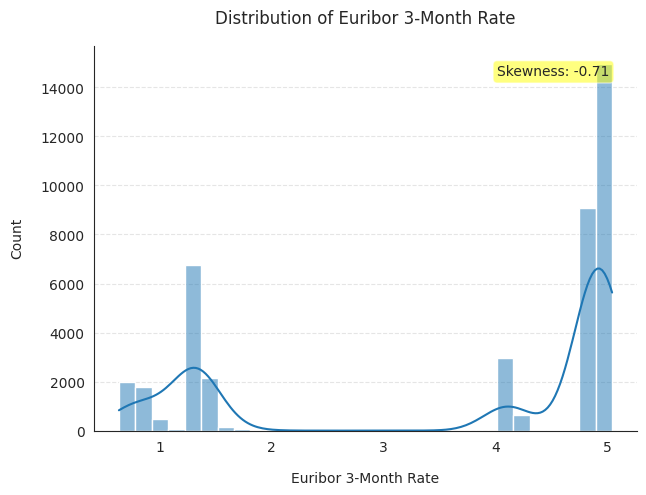

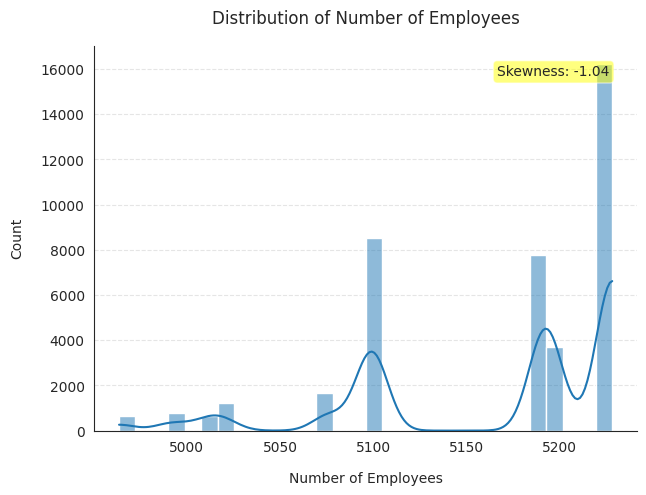

In [10]:
for col in numerical_cols:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.histplot(marketing[col], kde=True, bins=30)
    plt.title(f'Distribution of {feature_labels.get(col, col)}', pad=16)
    plt.text(
        0.95, 0.95, f'Skewness: {marketing[col].skew():.2f}', transform=ax.transAxes,
        horizontalalignment='right', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
    )
    plt.xlabel(feature_labels.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'Distribution of {col}.png', dpi=300)
    plt.show()
    print('\n')

### 4.3 Categorical distributions

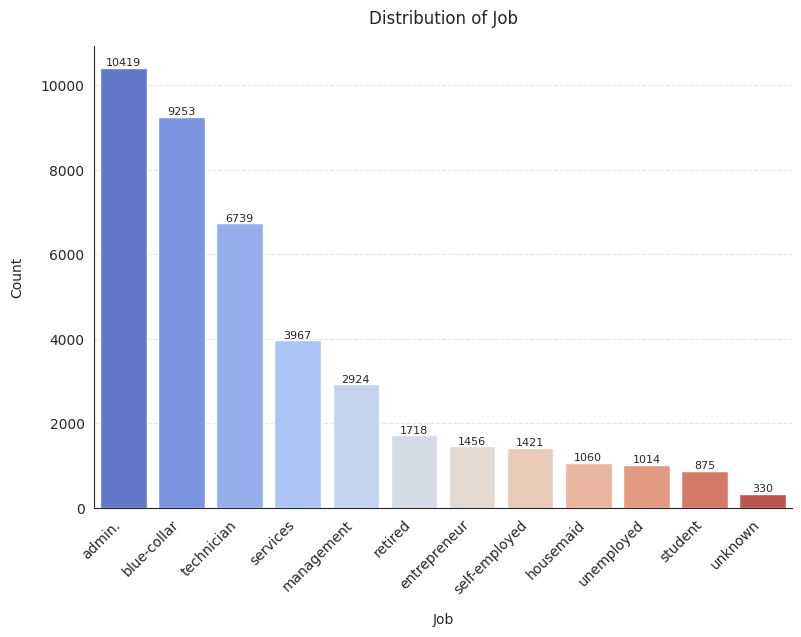

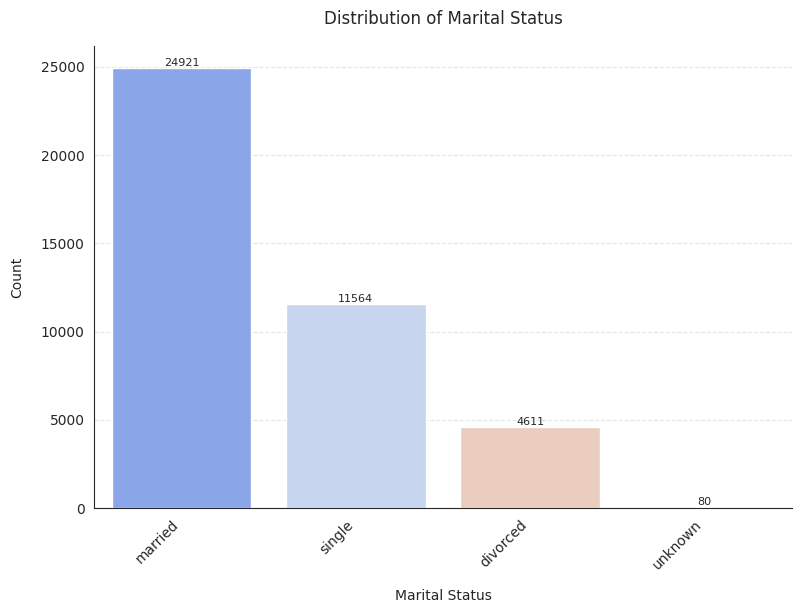

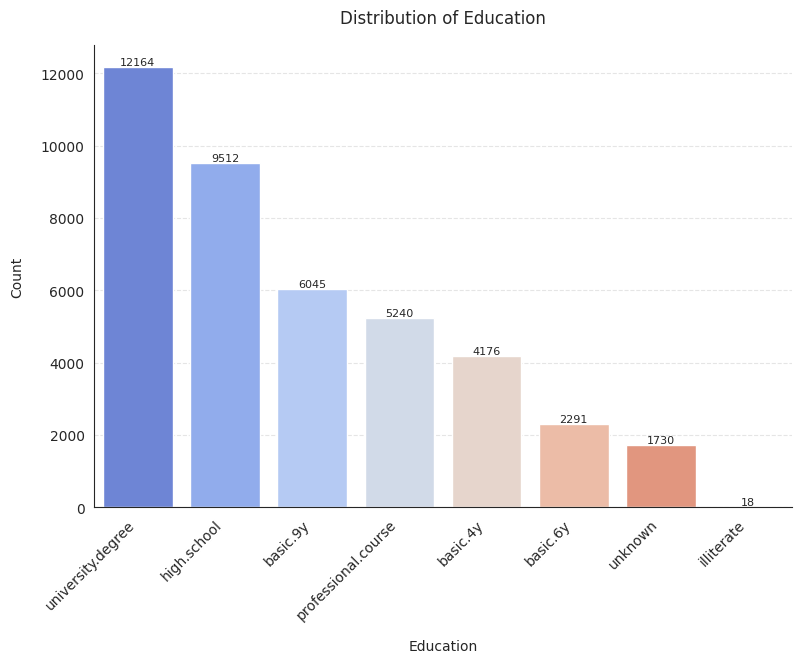

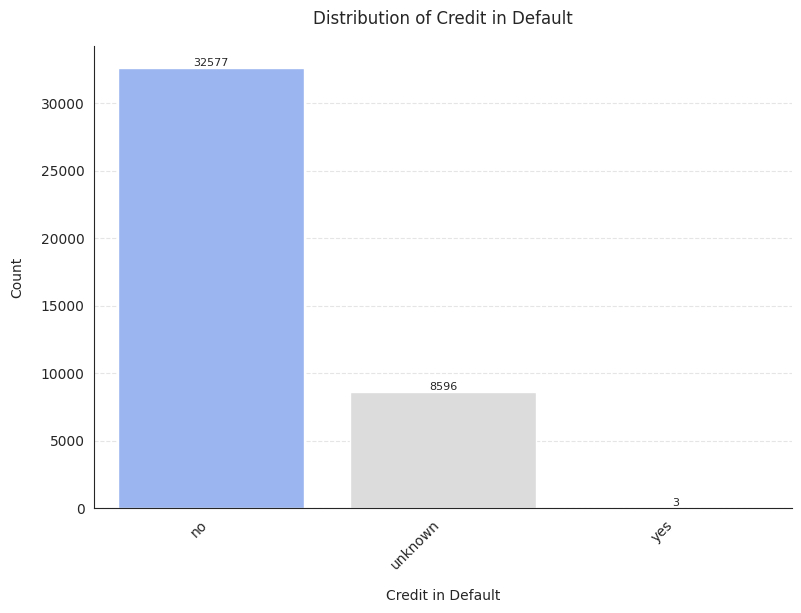

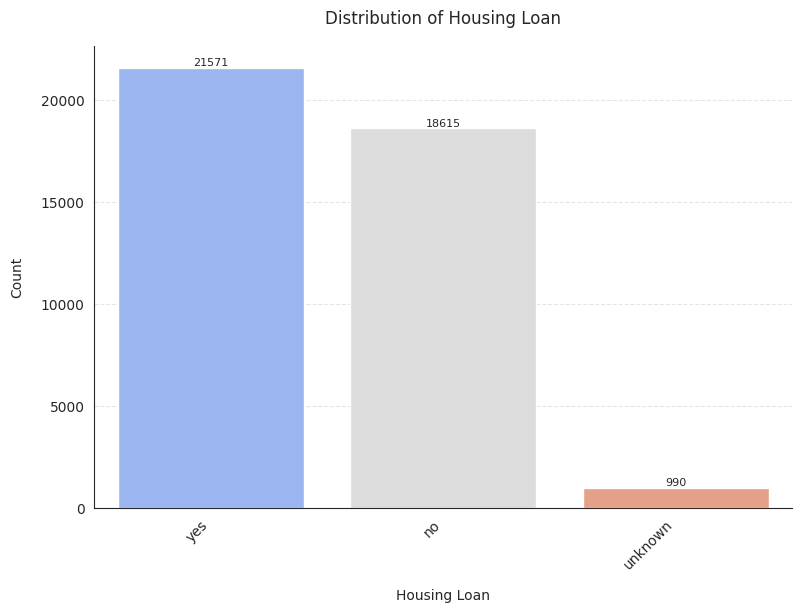

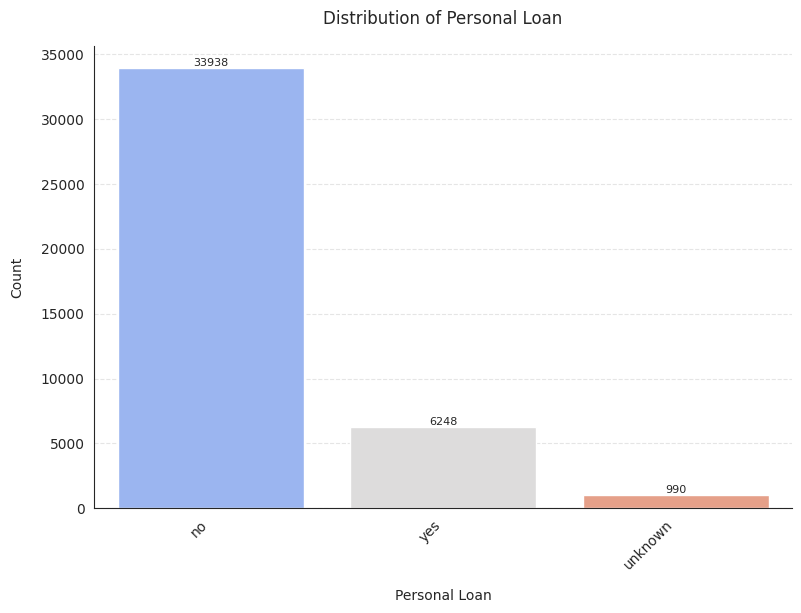

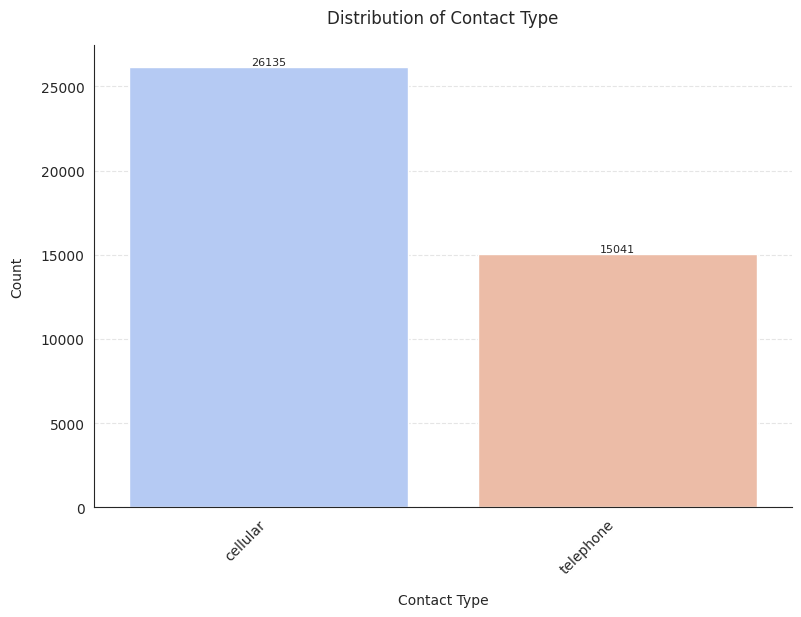

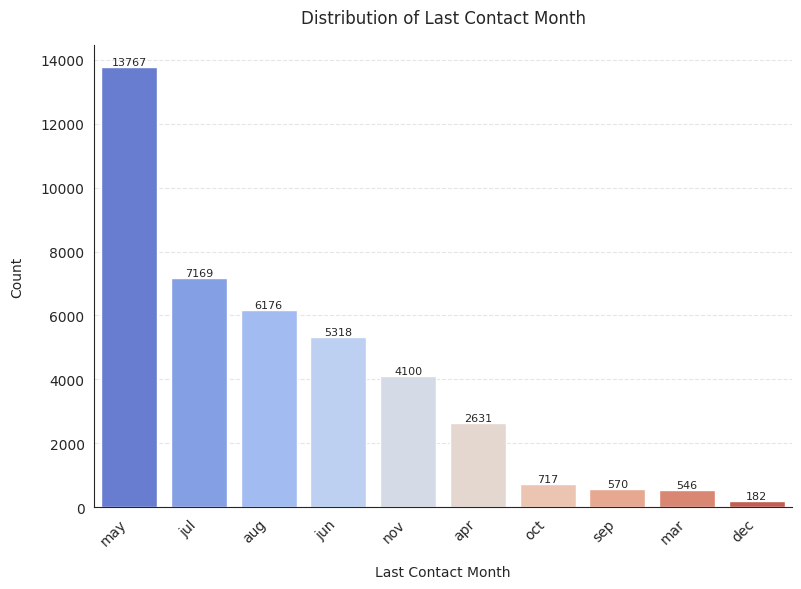

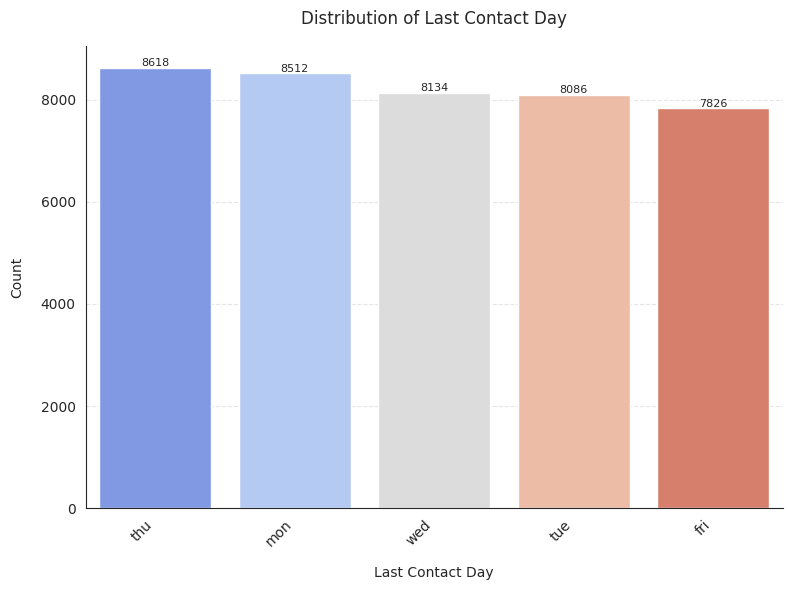

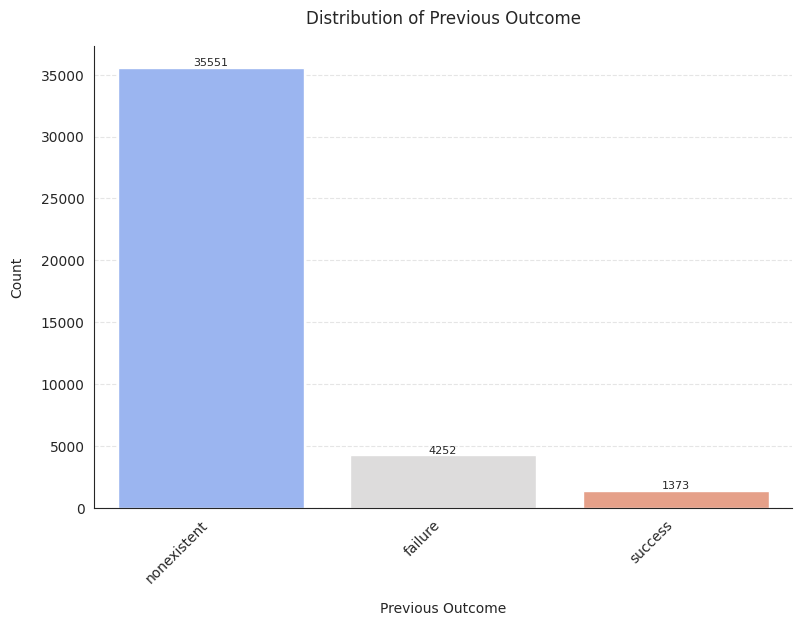

In [11]:
for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(9, 6), dpi=100)
    order = marketing[col].value_counts().index
    sns.countplot(data=marketing, x=col, palette='coolwarm', ax=ax, order=order)
    plt.title(f'Distribution of {feature_labels.get(col, col)}', pad=16)
    plt.xlabel(feature_labels.get(col, col), labelpad=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count', labelpad=12)
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'Distribution of {col}.png', dpi=300)
    plt.show()
    print('\n')

### 4.4 Subscription rate by category

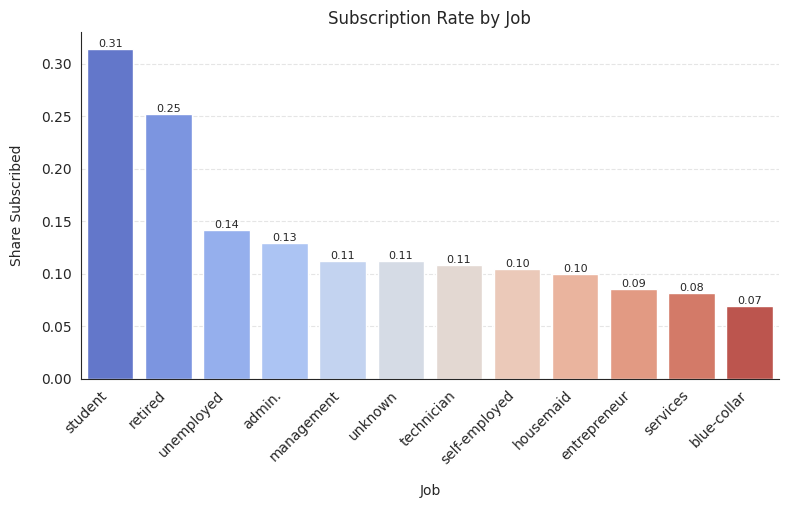

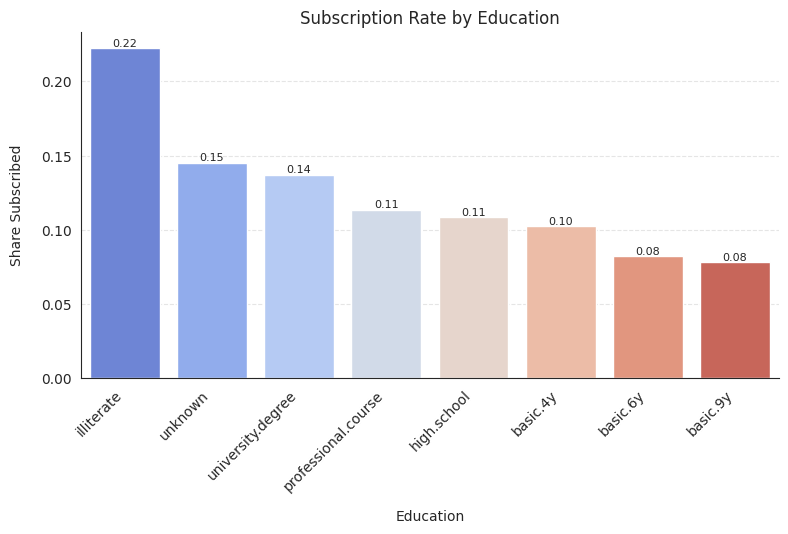

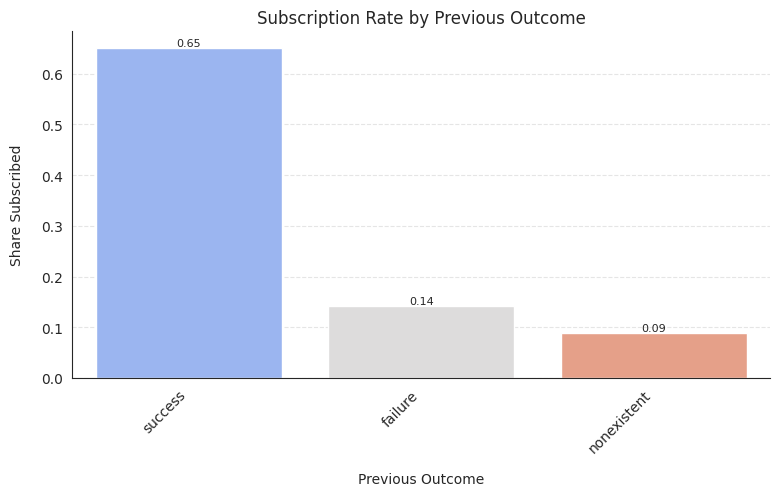

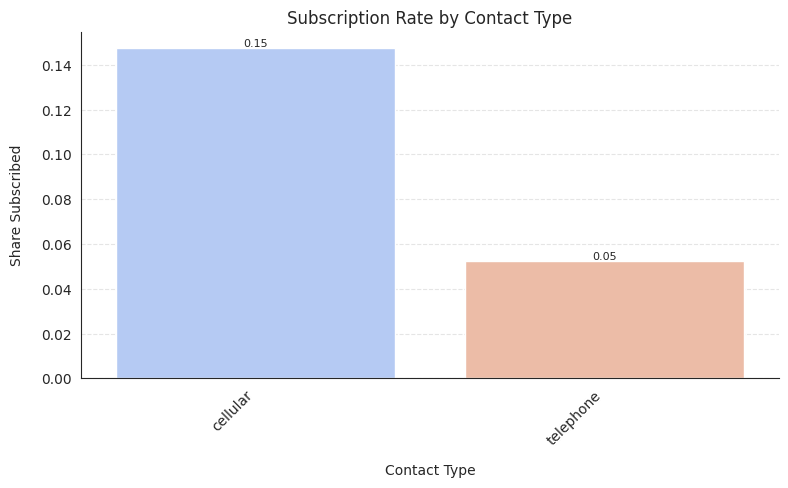

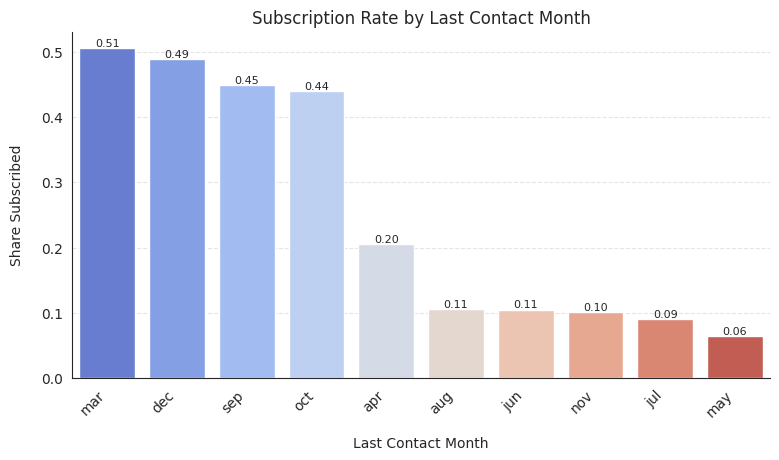

In [12]:
# Which categories convert best? More informative than raw counts on an imbalanced target.
for col in ['job', 'education', 'poutcome', 'contact', 'month']:
    rate = (marketing.groupby(col)['y']
                .apply(lambda s: (s == 'yes').mean())
                .sort_values(ascending=False))
    fig, ax = plt.subplots(figsize=(9, 4.5), dpi=100)
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index,
                palette='coolwarm', legend=False, ax=ax)
    ax.set_title(f'Subscription Rate by {feature_labels[col]}')
    ax.set_ylabel('Share Subscribed', labelpad=12)
    ax.set_xlabel(feature_labels[col], labelpad=12)
    plt.xticks(rotation=45, ha='right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=8)
    sns.despine(top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'rate_by_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('\n')

### 4.5 Correlation heatmap

This heatmap is the evidence behind the multicollinearity decision taken in section 5.2. It shows pairwise association between every numerical feature, so the block of economic indicators that move together is visible directly.

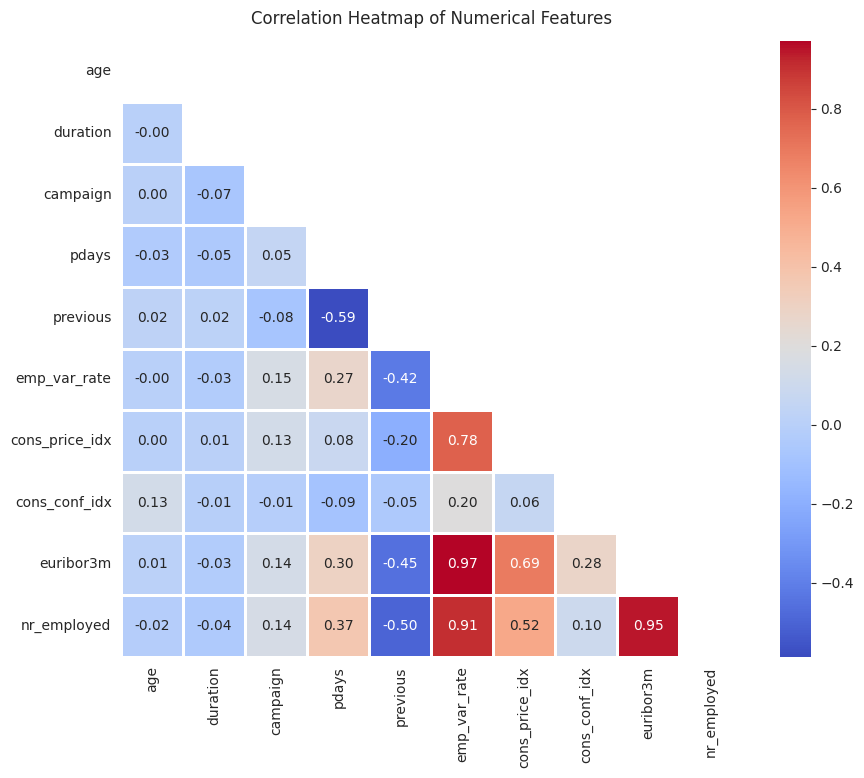

Strongest absolute correlations:
euribor3m       emp_var_rate      0.972
nr_employed     euribor3m         0.945
emp_var_rate    nr_employed       0.907
cons_price_idx  emp_var_rate      0.775
euribor3m       cons_price_idx    0.688
dtype: float64


In [13]:
corr = marketing[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.subplots(figsize=(10, 8), dpi=100)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=1, cbar=True)
plt.title('Correlation Heatmap of Numerical Features', pad=12)
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Strongest pairwise correlations, recorded for the write-up
pairs = (corr.where(~np.eye(len(corr), dtype=bool))
             .stack().abs().sort_values(ascending=False))
print('Strongest absolute correlations:')
print(pairs[::2].head(5).round(3))

## 5. Feature engineering

Four changes:

1. `pdays` uses 999 as a sentinel for "never contacted before". It becomes a binary `previously_contacted` flag plus `pdays_clean`, which keeps the true gap for contacted clients and uses -1 for the rest. The -1 matters: mapping never-contacted to 0 would collide with clients genuinely contacted zero days ago, which is a real value in this data.
2. `total_contacts` combines contacts in this campaign with contacts in earlier ones.
3. `age_group` is created for EDA. It stays out of the model because raw `age` already carries the signal and the models can learn their own cut points.
4. `campaign` is capped later, after the split, using bounds computed on training data only (section 6).

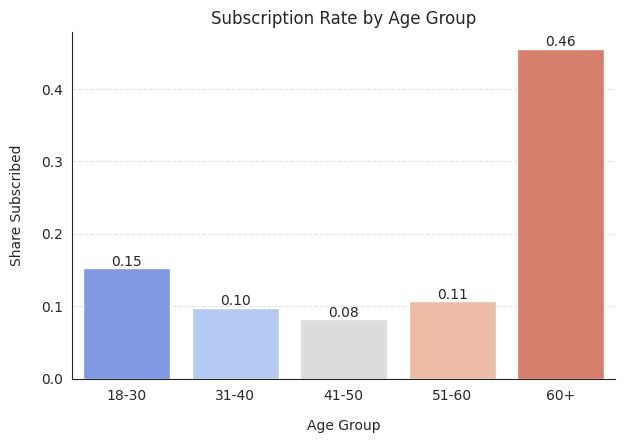

In [14]:
# 1. pdays sentinel handling.
#    pdays holds days since the client was last contacted in an earlier campaign,
#    with 999 standing in for "never contacted". Split it into two honest columns:
#    one for whether there was prior contact, one for how long ago it was.
marketing['was_contacted_before'] = (marketing['pdays'] != 999).astype(int)

#    -1 rather than 0 for never-contacted clients, because 0 is a real value in
#    this data (some clients were contacted the same day) and the two must not collide.
marketing['days_since_last_contact'] = np.where(
    marketing['pdays'] == 999, -1, marketing['pdays'])

# 2. Total contact pressure across campaigns
marketing['total_contacts'] = marketing['campaign'] + marketing['previous']

# 3. Age groups (EDA only, dropped before modelling)
age_bins = [17, 30, 40, 50, 60, 100]
age_labels = ['18-30', '31-40', '41-50', '51-60', '60+']
marketing['age_group'] = pd.cut(marketing['age'], bins=age_bins, labels=age_labels)

# Readable labels so the new columns are self-explanatory on charts
feature_labels['was_contacted_before'] = 'Contacted in a Previous Campaign (1 = yes)'
feature_labels['days_since_last_contact'] = 'Days Since Previous Contact (-1 = never)'
feature_labels['total_contacts'] = 'Total Contacts'
feature_labels['age_group'] = 'Age Group'

# Subscription rate by age group
rate = marketing.groupby('age_group', observed=True)['y'].apply(lambda s: (s == 'yes').mean())
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)
sns.barplot(x=rate.index, y=rate.values, hue=rate.index,
            palette='coolwarm', legend=False, ax=ax)
ax.set_title('Subscription Rate by Age Group')
ax.set_ylabel('Share Subscribed', labelpad=12)
ax.set_xlabel('Age Group', labelpad=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')
sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('rate_by_age_group.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.1 Outlier check

Outliers are kept because some tail contact carry significant signal

In [15]:
def count_outliers(df, cols):
    """IQR-based outlier count per column."""
    counts = {}
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())
    return pd.DataFrame({'Outlier Count': counts})

count_outliers(marketing, numerical_cols + ['total_contacts'])

,Outlier Count
age,468
duration,2963
campaign,2406
pdays,1515
previous,5625
emp_var_rate,0
cons_price_idx,0
cons_conf_idx,446
euribor3m,0
nr_employed,0


### 5.2 Removing redundant economic indicators

The heatmap in section 4.5 shows that the employment variation rate, the number of employees and the Euribor rate are almost perfectly correlated, because all three track the same economic cycle. I keep the Euribor rate as the single economic-cycle indicator and drop the other two.


In [24]:
# Drop the redundant economic indicators
redundant = ['emp_var_rate', 'nr_employed']
marketing = marketing.drop(columns=redundant, errors='ignore')

# Recompute the column groups so nothing downstream uses a stale list
numerical_cols = marketing.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = marketing.select_dtypes(include='object').drop(columns='y').columns.tolist()

# Keep the label dictionary consistent with the data
for col in redundant:
    feature_labels.pop(col, None)

print(f'Dropped: {redundant}')

print('Numeric columns remaining:', numerical_cols)

Dropped: ['emp_var_rate', 'nr_employed']
Categorical columns remaining: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns remaining: ['age', 'duration', 'campaign', 'pdays', 'previous', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'was_contacted_before', 'days_since_last_contact', 'total_contacts']


## 6. Pre-processing and splitting

The target is encoded first, then features and target are separated. The split runs before any fitting so scaler statistics and encoder categories come from training data only. SMOTE sits inside the pipeline, which means it only ever oversamples the training folds, never validation or test rows.

In [20]:
# Encode target
target = marketing['y'].map({'no': 0, 'yes': 1})

# Evidence for the leakage argument: correlation of duration with the target
duration_corr = marketing['duration'].corr(target)
print(f'Correlation of duration with the target: {duration_corr:.3f}')
print('This is only knowable after the call ends, hence the exclusion below.\n')

drop_cols = ['y', 'age_group', 'pdays']  # pdays replaced by previously_contacted and pdays_clean
if DROP_DURATION:
    drop_cols.append('duration')

features = marketing.drop(columns=drop_cols)
print(f'Modelling with {features.shape[1]} features: {features.columns.tolist()}')

Correlation of duration with the target: 0.405
This is only knowable after the call ends, hence the exclusion below.

Modelling with 19 features: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'was_contacted_before', 'days_since_last_contact', 'total_contacts']


In [21]:
# Column groups for the transformer
num_features = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

education_order = ['unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree']
ord_features = ['education']

cat_features = [c for c in features.select_dtypes(include='object').columns
                if c not in ord_features]

print('Numerical:', num_features)
print('Ordinal:  ', ord_features)
print('Nominal:  ', cat_features)

Numerical: ['age', 'campaign', 'previous', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'was_contacted_before', 'days_since_last_contact', 'total_contacts']
Ordinal:   ['education']
Nominal:   ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [22]:
# Stratified 70 / 15 / 15 split so every set keeps the same class ratio
X_train_full, X_test, y_train_full, y_test = train_test_split(
    features, target, test_size=0.15, stratify=target, random_state=RANDOM_STATE)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1765,  # 0.1765 of 85% = 15% overall
    stratify=y_train_full, random_state=RANDOM_STATE)

# Take explicit copies: the splits are views of `features`, and section 6.1 writes
# into them. Without this, pandas raises SettingWithCopyWarning and the write may
# not persist.
X_train, X_valid, X_test = X_train.copy(), X_valid.copy(), X_test.copy()

for name, y_part in [('train', y_train), ('validation', y_valid), ('test', y_test)]:
    print(f'{name:<11} {len(y_part):>6} rows, {y_part.mean():.1%} positive')

train        28821 rows, 11.3% positive
validation    6178 rows, 11.3% positive
test          6177 rows, 11.3% positive


In [23]:
preprocessor = ColumnTransformer([
    ('scaler', RobustScaler(), num_features),
    ('ordinal', OrdinalEncoder(categories=[education_order],
                               handle_unknown='use_encoded_value',
                               unknown_value=-1), ord_features),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier())  # placeholder, swapped per model below
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', RobustScaler(),
                                                  ['age', 'campaign',
                                                   'previous', 'cons_price_idx',
                                                   'cons_conf_idx', 'euribor3m',
                                                   'was_contacted_before',
                                                   'days_since_last_contact',
                                                   'total_contacts']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['unknown',
                                                                              'illiterate',
                                                                              'basic.4y',
                                                                              'basic.6y',
                                                                              'basic.9y',
                                                                              'high.school',
                                                                              'professional.course',
                                                                              'university.degree']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['education']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier())])

### 6.1 Capping extreme contact counts

`campaign` has a long right tail (a few clients were called over 40 times). Rather than deleting those rows, the value is capped at the IQR upper bound. The bound is computed on training data only and then applied to all three splits, so no information flows backwards from validation or test rows.

In [ ]:
def iqr_bounds(series):
    """Lower and upper IQR bounds for a numeric series."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Bounds from training data only
campaign_lower, campaign_upper = iqr_bounds(X_train['campaign'])
print(f'campaign capped at {campaign_upper:.1f} (bound computed on training data)')
print(f"Training rows affected: {(X_train['campaign'] > campaign_upper).sum()}")

for part in (X_train, X_valid, X_test):
    part['campaign'] = part['campaign'].clip(upper=campaign_upper)

# Cap total_contacts consistently, with the bound also derived from training data
total_upper = campaign_upper + X_train['previous'].max()
for part in (X_train, X_valid, X_test):
    part['total_contacts'] = part['total_contacts'].clip(upper=total_upper)

campaign capped at 6.0 (bound computed on training data)
Training rows affected: 1707


### 6.2 Class balance before and after SMOTE

SMOTE lives inside the pipeline, so during training it only ever sees the training folds. This cell demonstrates what it does: the preprocessor is fitted on training data, SMOTE resamples it, and the counts are compared. This is a demonstration only; the modelling pipelines refit from scratch.

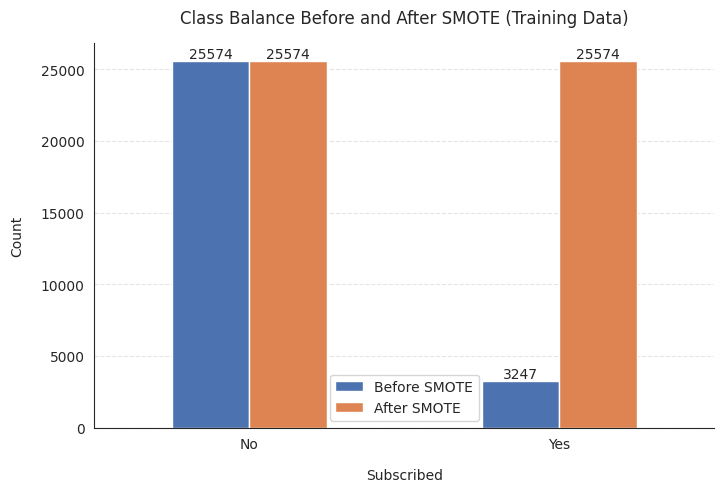

     Before SMOTE  After SMOTE
y                             
No          25574        25574
Yes          3247        25574


In [ ]:
demo_transformed = preprocessor.fit_transform(X_train)
X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(demo_transformed, y_train)

balance_df = pd.DataFrame({
    'Before SMOTE': y_train.value_counts().sort_index(),
    'After SMOTE': pd.Series(y_res).value_counts().sort_index()
}).rename(index={0: 'No', 1: 'Yes'})

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
balance_df.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.title('Class Balance Before and After SMOTE (Training Data)', pad=14)
plt.xlabel('Subscribed', labelpad=12)
plt.ylabel('Count', labelpad=12)
plt.xticks(rotation=0)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('smote_class_balance.png', dpi=300, bbox_inches='tight')
plt.show()

print(balance_df)

## 7. Baseline training

Four models with default parameters. Each is evaluated on the validation set: classification report, confusion matrix, and stored metrics and ROC data for the comparison plots.

In [ ]:
models = {
    'lgbm': {'name': 'LightGBM',
             'model': LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1)},
    'xgb':  {'name': 'XGBoost',
             'model': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')},
    'rfc':  {'name': 'Random Forest',
             'model': RandomForestClassifier(random_state=RANDOM_STATE)},
    'lgr':  {'name': 'Logistic Regression',
             'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)},
}

In [ ]:
def evaluate_model(fitted_pipeline, name, X_eval, y_eval, tag='',
                   fit_seconds=None, tuning_seconds=None):
    """Report, confusion matrix and metric dictionary for one fitted pipeline.

    fit_seconds    time to fit a single model (baseline runs)
    tuning_seconds time for the whole hyperparameter search (tuned runs)
    The two are kept in separate columns because they are not comparable.
    """
    y_pred = fitted_pipeline.predict(X_eval)
    y_proba = fitted_pipeline.predict_proba(X_eval)[:, 1]

    print('-' * 90)
    print(f'--> {name}{tag} <--')
    if fit_seconds is not None:
        print(f'Fit time: {fit_seconds:.2f} seconds')
    if tuning_seconds is not None:
        print(f'Search time: {tuning_seconds:.2f} seconds')
    print('-' * 90)
    print(classification_report(y_eval, y_pred))

    cm = confusion_matrix(y_eval, y_pred)
    plt.subplots(figsize=(6, 5), dpi=100)
    labels = ['No', 'Yes']
    sns.heatmap(cm, annot=True, fmt='d', cbar=True, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label', labelpad=12)
    plt.ylabel('True Label', labelpad=12)
    plt.title(f'Confusion Matrix: {name}{tag}', pad=14)
    plt.savefig(f'confusion_{name}{tag}.png'.replace(' ', '_'),
                dpi=300, bbox_inches='tight')
    plt.show()

    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    precision_c, recall_c, _ = precision_recall_curve(y_eval, y_proba)

    return {
        'name': name,
        'Fit (s)': fit_seconds,
        'Search (s)': tuning_seconds,
        'Accuracy': accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred),
        'Recall': recall_score(y_eval, y_pred),
        'F1-score': f1_score(y_eval, y_pred),
        'ROC-AUC': roc_auc_score(y_eval, y_proba),
        'Avg Precision': average_precision_score(y_eval, y_proba),
        'fpr': fpr, 'tpr': tpr,
        'precision_curve': precision_c, 'recall_curve': recall_c
    }


def show_sample_predictions(fitted_pipeline, name, X_eval, y_eval, n=10):
    """Show a sample of predictions against true labels."""
    y_pred = fitted_pipeline.predict(X_eval)
    sample = pd.DataFrame({
        'True Label': y_eval.values,
        'Predicted Label': y_pred,
        'Correct': np.where(y_pred == y_eval.values, 'Yes', 'No')
    }).sample(n, random_state=RANDOM_STATE)
    print(f'Sample predictions by {name}:')
    print(sample.to_string(index=False), '\n')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


------------------------------------------------------------------------------------------
--> LightGBM <--
Fit time: 1.56 seconds
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5482
           1       0.58      0.33      0.42       696

    accuracy                           0.90      6178
   macro avg       0.75      0.65      0.68      6178
weighted avg       0.88      0.90      0.89      6178



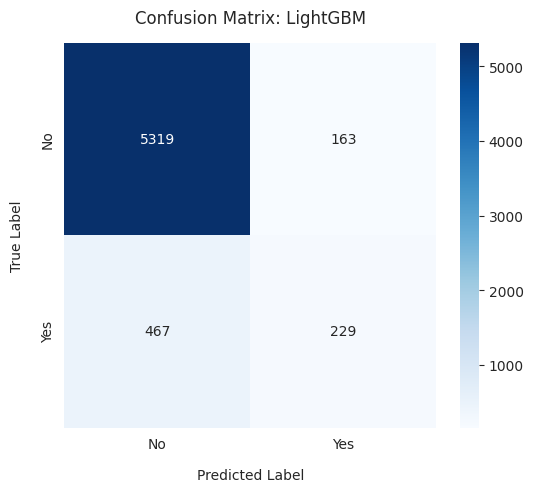

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Sample predictions by LightGBM:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

------------------------------------------------------------------------------------------
--> XGBoost <--
Fit time: 3.53 seconds
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5482
           1       0.60      0.31      0.41       696

    accuracy                           0.90      6178
   macro avg       0.76      0.64      0.68      6178
weighted avg       0.88      0.90      0.88      6178



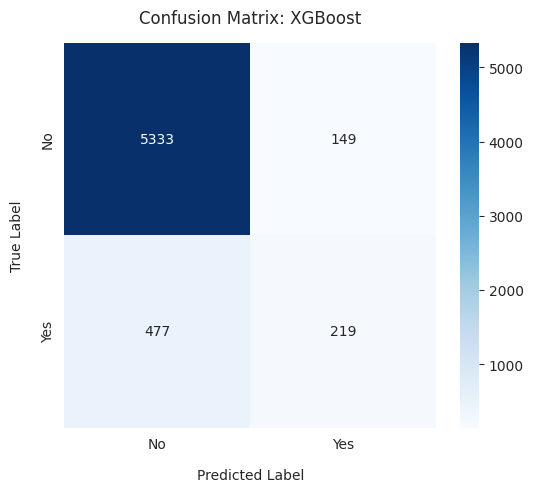

Sample predictions by XGBoost:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                0     Yes
          1                0      No
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

------------------------------------------------------------------------------------------
--> Random Forest <--
Fit time: 8.02 seconds
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      5482
           1       0.50      0.35      0.41       696

    accuracy                           0.89      6178
   macro avg       0.71      0.65      0.68      6178
weighted avg       0.87      0.89      0.88      6178



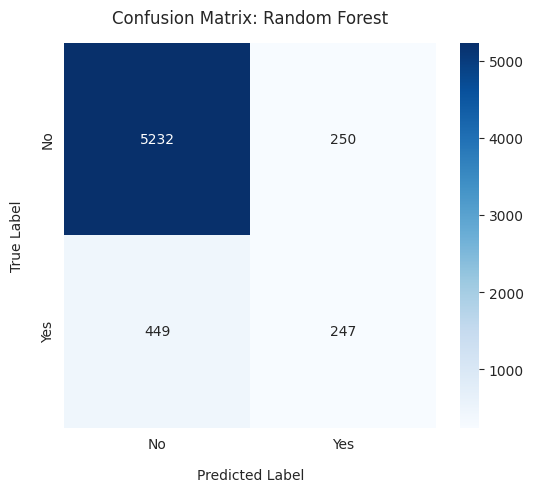

Sample predictions by Random Forest:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                0      No
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

------------------------------------------------------------------------------------------
--> Logistic Regression <--
Fit time: 2.40 seconds
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      5482
           1       0.33      0.62      0.43       696

    accuracy                           0.81      6178
   macro avg       0.64      0.73      0.66      6178
weighted avg       0.88      0.81      0.84      

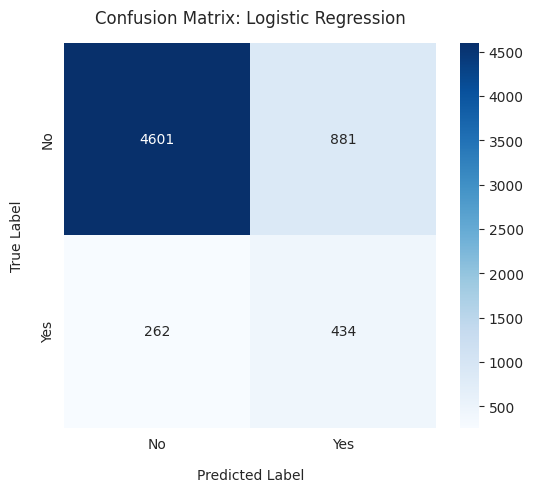

Sample predictions by Logistic Regression:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                0      No
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 



In [ ]:
baseline_results = {}

for abbr, spec in models.items():
    pipeline.set_params(model=spec['model'])

    start_time = time.time()
    pipeline.fit(X_train, y_train)
    elapsed = time.time() - start_time

    baseline_results[abbr] = evaluate_model(
        pipeline, spec['name'], X_valid, y_valid, fit_seconds=elapsed)
    show_sample_predictions(pipeline, spec['name'], X_valid, y_valid)

## 8. Baseline model comparison





In [ ]:
METRIC_COLS = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'Avg Precision']


def compare_metrics(results):
    """Display and return a DataFrame of metrics across all models.

    Timing columns are included only when they hold values, and fit time and
    search time are kept separate because they measure different things.
    """
    time_cols = [c for c in ['Fit (s)', 'Search (s)']
                 if any(r.get(c) is not None for r in results.values())]
    cols = ['name'] + time_cols + METRIC_COLS
    df = pd.DataFrame([{k: r.get(k) for k in cols} for r in results.values()])
    display(df.set_index('name').round(3))
    return df

In [ ]:
baseline_df = compare_metrics(baseline_results)

,Fit (s),Accuracy,Precision,Recall,F1-score,ROC-AUC,Avg Precision
name,,,,,,,
LightGBM,1.565,0.898,0.584,0.329,0.421,0.788,0.468
XGBoost,3.532,0.899,0.595,0.315,0.412,0.773,0.451
Random Forest,8.023,0.887,0.497,0.355,0.414,0.774,0.407
Logistic Regression,2.399,0.815,0.330,0.624,0.432,0.778,0.419


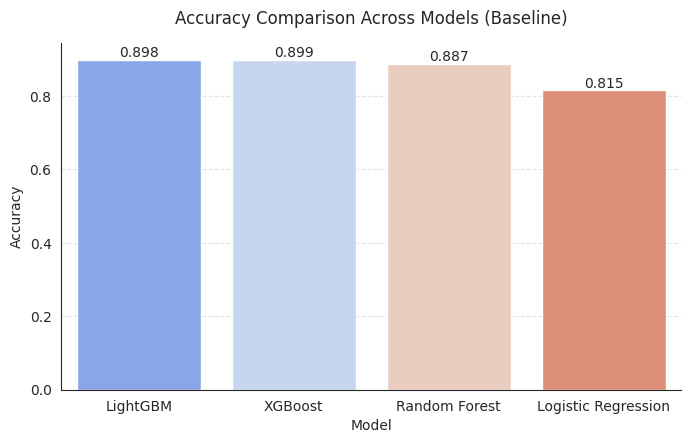

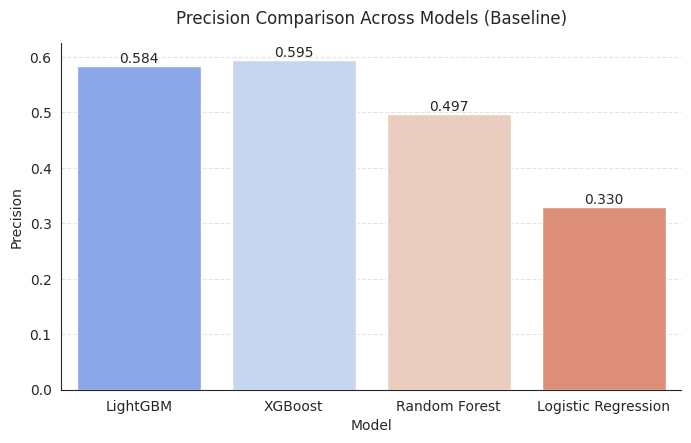

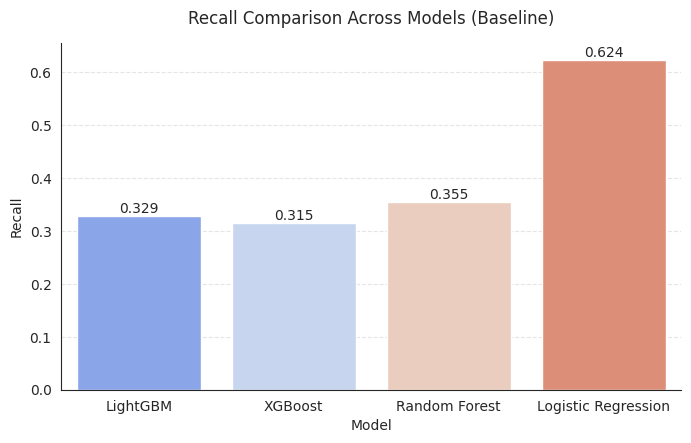

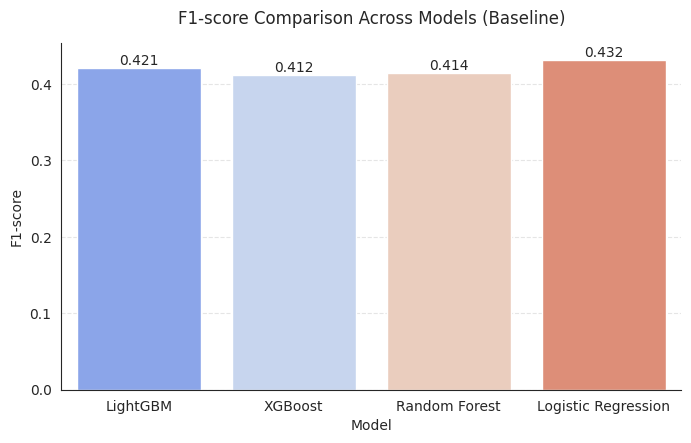

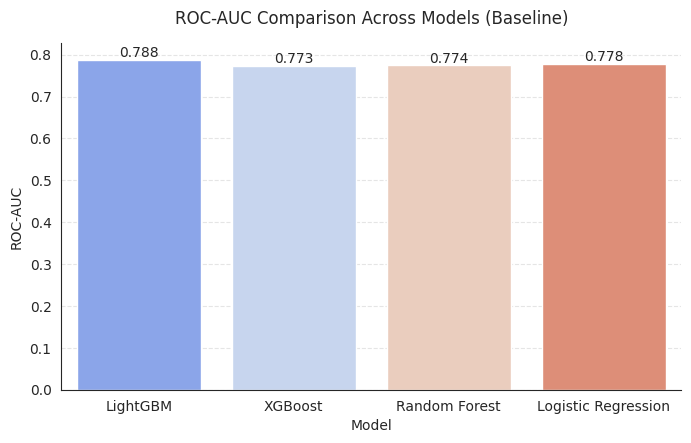

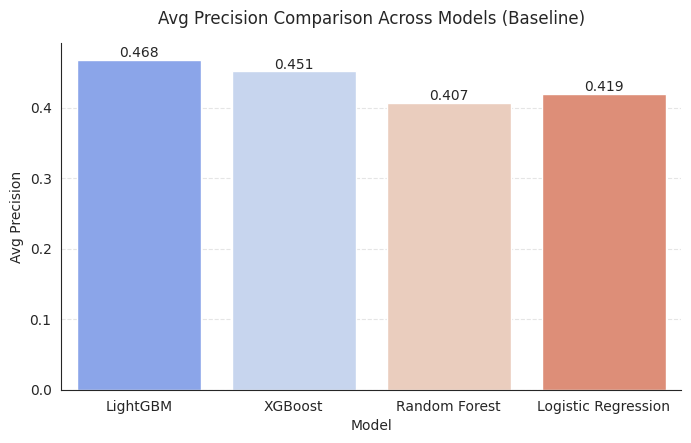

In [ ]:
def plot_metric_bar_chart(df, metric, tag=''):
    """Bar chart of one metric across all models."""
    plt.figure(figsize=(8, 4.5), dpi=100)
    ax = sns.barplot(data=df, x='name', y=metric, hue='name',
                     palette='coolwarm', legend=False)
    plt.title(f'{metric} Comparison Across Models{tag}', pad=14)
    plt.ylabel(metric)
    plt.xlabel('Model')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', label_type='edge')
    sns.despine()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'{metric}_comparison{tag}.png'.replace(' ', '_'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print('\n')

for metric in METRIC_COLS:
    plot_metric_bar_chart(baseline_df, metric, tag=' (Baseline)')

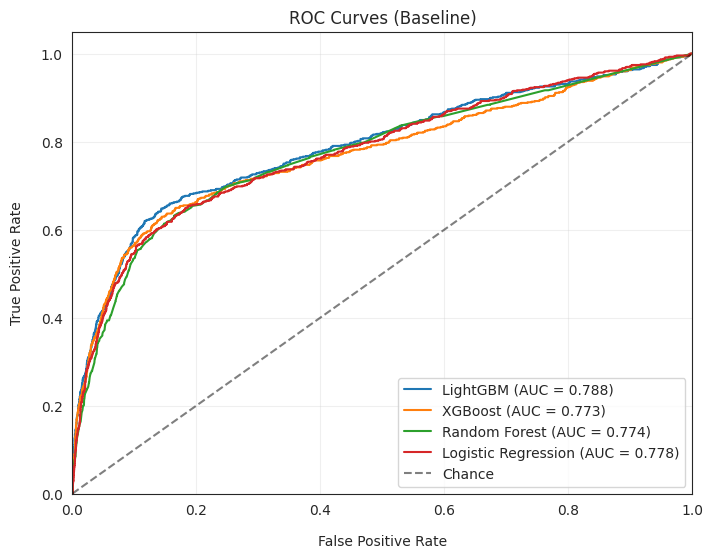

In [ ]:
def plot_roc_curves(results, tag=''):
    """ROC curves for every model, with AUC in the legend."""
    plt.figure(figsize=(8, 6), dpi=100)
    for abbr, res in results.items():
        plt.plot(res['fpr'], res['tpr'],
                 label=f"{res['name']} (AUC = {res['ROC-AUC']:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Chance')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', labelpad=12)
    plt.ylabel('True Positive Rate', labelpad=12)
    plt.title(f'ROC Curves{tag}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.savefig(f'roc_curves{tag}.png'.replace(' ', '_'), dpi=300, bbox_inches='tight')
    plt.show()


def plot_pr_curves(results, y_true, tag=''):
    """Precision-recall curves, which are more informative than ROC under imbalance."""
    plt.figure(figsize=(8, 6), dpi=100)
    baseline_rate = y_true.mean()
    plt.axhline(y=baseline_rate, color='k', linestyle='--', alpha=0.5,
                label=f'Chance (base rate = {baseline_rate:.3f})')
    for abbr, res in results.items():
        plt.plot(res['recall_curve'], res['precision_curve'],
                 label=f"{res['name']} (AP = {res['Avg Precision']:.3f})")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', labelpad=12)
    plt.ylabel('Precision', labelpad=12)
    plt.title(f'Precision-Recall Curves{tag}')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.savefig(f'pr_curves{tag}.png'.replace(' ', '_'), dpi=300, bbox_inches='tight')
    plt.show()


plot_roc_curves(baseline_results, tag=' (Baseline)')

ROC-AUC is optimistic on imbalanced data, because the false positive rate is diluted by the large negative class. The precision-recall curve below describes the same models from the perspective of the minority class, with the dashed line marking random guessing.

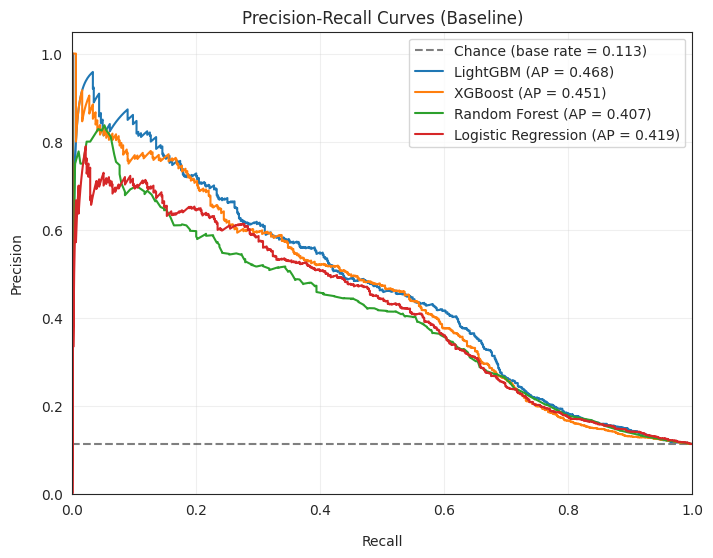

In [ ]:
plot_pr_curves(baseline_results, y_valid, tag=' (Baseline)')

## 9. Hyperparameter tuning

RandomizedSearchCV with F1 scoring, 3-fold cross validation and 30 sampled parameter combinations per model. Randomised search is used rather than grid search because the tree models have five to seven interacting parameters; sampling the joint space finds strong configurations at a fraction of the cost of exhaustive search. The fold-to-fold spread of each winning configuration is also recorded, so the model ranking can be reported with an uncertainty estimate in section 10.1.

In [ ]:
N_ITER = 30
CV_FOLDS = 3

# Define the hyperparameter search space for each model type
param_grids = {
    'lgbm': {
        'model__num_leaves': [15, 31, 63],
        'model__max_depth': [-1, 5, 8, 12],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__n_estimators': [200, 400, 800],
        'model__min_child_samples': [20, 50, 100],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.7, 0.85, 1.0],
    },
    'xgb': {
        'model__n_estimators': [200, 400, 800],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.7, 0.85, 1.0],
        'model__min_child_weight': [1, 5, 10],
        'model__gamma': [0, 0.1, 0.2],
    },
    'rfc': {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [10, 20, 30, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2'],
    },
    'lgr': {
        'model__C': [0.01, 0.1, 1, 10, 50],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['saga'],
    },
}

# Record the size of each search space, for the write-up
for abbr, grid in param_grids.items():
    total = int(np.prod([len(v) for v in grid.values()]))
    print(f"{models[abbr]['name']:<20} {total:>5} combinations, sampling {N_ITER} "
          f"({N_ITER / total:.1%})")

LightGBM              2916 combinations, sampling 30 (1.0%)
XGBoost               2187 combinations, sampling 30 (1.4%)
Random Forest          216 combinations, sampling 30 (13.9%)
Logistic Regression     10 combinations, sampling 30 (300.0%)


Best CV F1 for LightGBM: 0.4952 (+/- 0.0099 across 3 folds)
Search time: 333.18 seconds
Best parameters: {'model__subsample': 0.85, 'model__num_leaves': 63, 'model__n_estimators': 200, 'model__min_child_samples': 50, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


------------------------------------------------------------------------------------------
--> LightGBM (Tuned) <--
Search time: 333.18 seconds
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      5482
           1       0.45      0.55      0.49       696

    accuracy                           0.87      6178
   macro avg       0.70      0.73      0.71      6178
weighted avg       0.89      0.87      0.88      6178



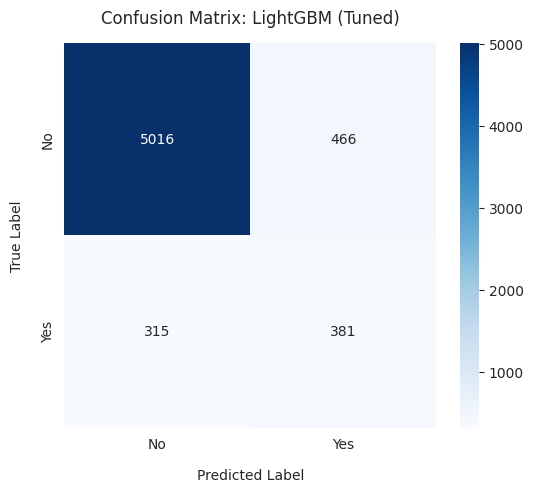

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Sample predictions by LightGBM:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                1     Yes
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 

Best CV F1 for XGBoost: 0.4883 (+/- 0.0071 across 3 folds)
Search time: 322.29 seconds
Best parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__gamma': 0, 'model__colsample_bytree': 0.7}

------------------------------------------------------------------------------------------
--> XGBoost (Tuned) <--
Search time: 322.29 seconds
------------------------------------------------------------------------------------------
              precision    recal

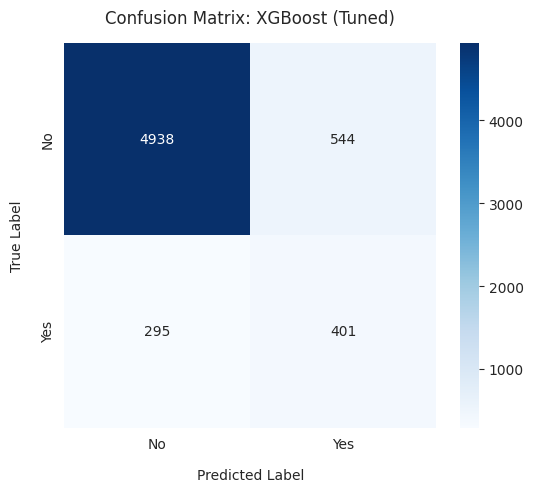

Sample predictions by XGBoost:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                1     Yes
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 



/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV F1 for Random Forest: 0.4907 (+/- 0.0083 across 3 folds)
Search time: 1149.99 seconds
Best parameters: {'model__n_estimators': 400, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 10}

------------------------------------------------------------------------------------------
--> Random Forest (Tuned) <--
Search time: 1149.99 seconds
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      5482
           1       0.43      0.56      0.49       696

    accuracy                           0.87      6178
   macro avg       0.69      0.73      0.71      6178
weighted avg       0.88      0.87      0.87      6178



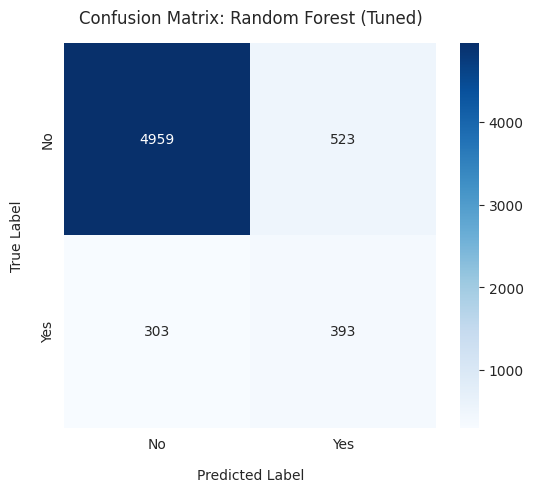

Sample predictions by Random Forest:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                1     Yes
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=30. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best CV F1 for Logistic Regression: 0.4290 (+/- 0.0016 across 3 folds)
Search time: 910.74 seconds
Best parameters: {'model__solver': 'saga', 'model__penalty': 'l1', 'model__C': 0.1}

------------------------------------------------------------------------------------------
--> Logistic Regression (Tuned) <--
Search time: 910.74 seconds
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      5482
           1       0.33      0.63      0.44       696

    accuracy                           0.82      6178
   macro avg       0.64      0.73      0.66      6178
weighted avg       0.88      0.82      0.84      6178



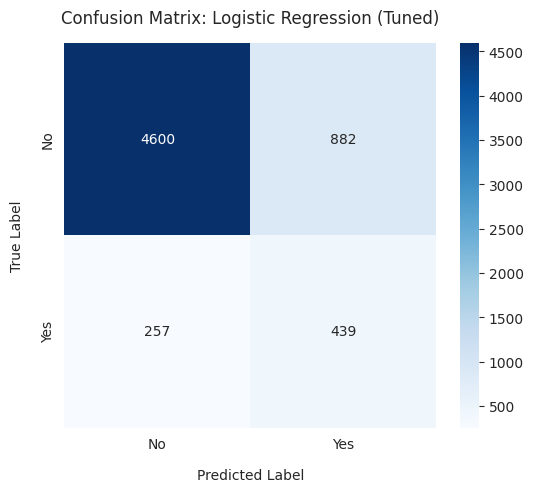

Sample predictions by Logistic Regression:
 True Label  Predicted Label Correct
          0                0     Yes
          0                0     Yes
          1                0      No
          0                1      No
          1                0      No
          0                0     Yes
          0                0     Yes
          1                1     Yes
          0                0     Yes
          0                0     Yes 



In [ ]:
tuned_results = {}
best_pipelines = {}
best_params = {}
search_records = {}

# Loop through each model to perform hyperparameter optimisation
for abbr, spec in models.items():
    # Swap the current algorithm into the pipeline's model step
    pipeline.set_params(model=spec['model'])

    # Cross-validate on F1 to find the best settings for this model
    search = RandomizedSearchCV(
        pipeline, param_grids[abbr], n_iter=N_ITER, cv=CV_FOLDS,
        scoring='f1', n_jobs=-1, random_state=RANDOM_STATE)

    start_t = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - start_t

    best_pipelines[abbr] = search.best_estimator_
    best_params[abbr] = search.best_params_

    # Keep the fold-level spread of the winning configuration. RandomizedSearchCV
    # already computes this; capturing it lets section 10.1 report whether the gap
    # between models is larger than the noise in the measurement.
    idx = search.best_index_
    search_records[abbr] = {
        'name': spec['name'],
        'mean_cv_f1': search.cv_results_['mean_test_score'][idx],
        'std_cv_f1': search.cv_results_['std_test_score'][idx],
        'search_seconds': elapsed,
    }

    print(f"Best CV F1 for {spec['name']}: {search.best_score_:.4f} "
          f"(+/- {search_records[abbr]['std_cv_f1']:.4f} across {CV_FOLDS} folds)")
    print(f"Search time: {elapsed:.2f} seconds")
    print(f"Best parameters: {search.best_params_}\n")

    # Evaluate the tuned model on the validation set
    tuned_results[abbr] = evaluate_model(
        search.best_estimator_, spec['name'], X_valid, y_valid,
        tag=' (Tuned)', tuning_seconds=elapsed)
    show_sample_predictions(search.best_estimator_, spec['name'], X_valid, y_valid)

## 10. Tuned model comparison

In [ ]:
tuned_df = compare_metrics(tuned_results)

,Search (s),Accuracy,Precision,Recall,F1-score,ROC-AUC,Avg Precision
name,,,,,,,
LightGBM,333.180,0.874,0.450,0.547,0.494,0.783,0.460
XGBoost,322.292,0.864,0.424,0.576,0.489,0.782,0.449
Random Forest,1149.994,0.866,0.429,0.565,0.488,0.784,0.452
Logistic Regression,910.737,0.816,0.332,0.631,0.435,0.778,0.421


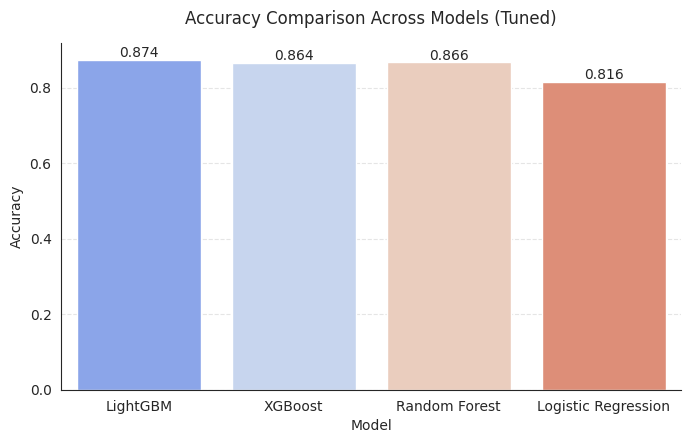

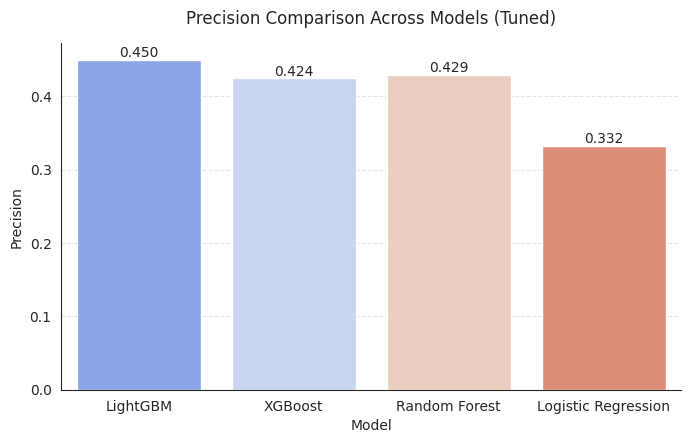

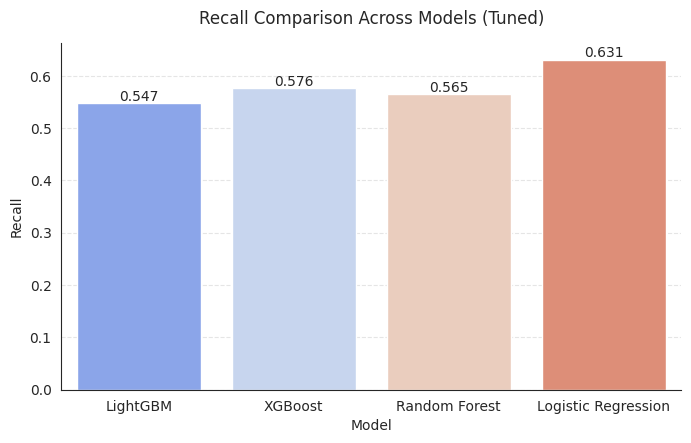

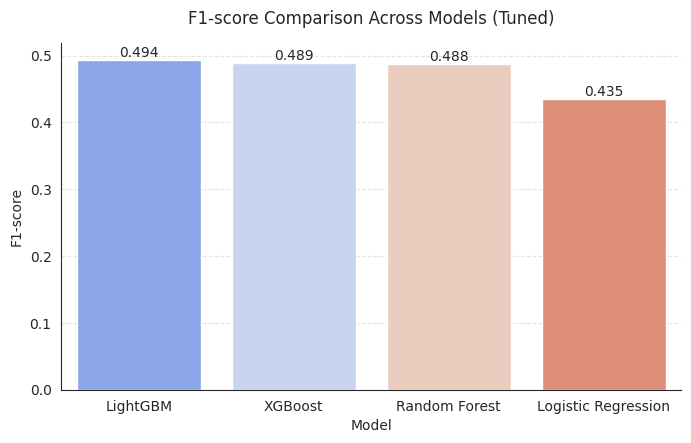

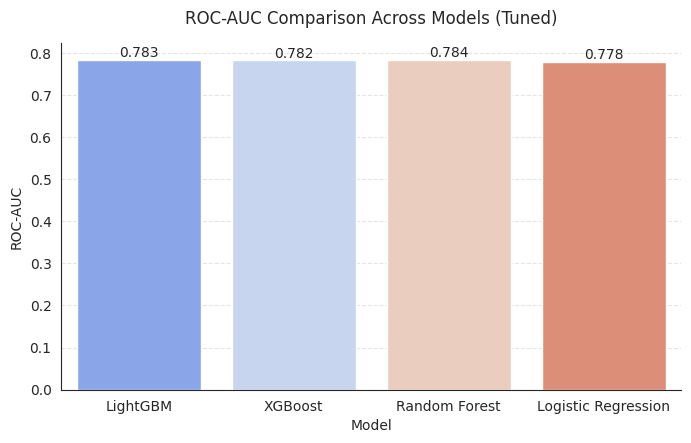

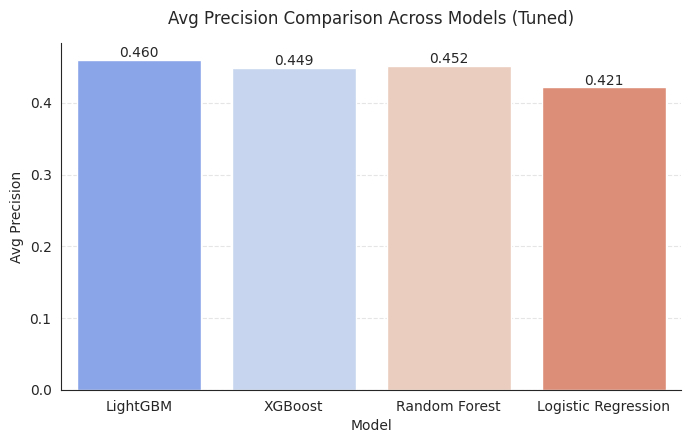

In [ ]:
for metric in METRIC_COLS:
    plot_metric_bar_chart(tuned_df, metric, tag=' (Tuned)')

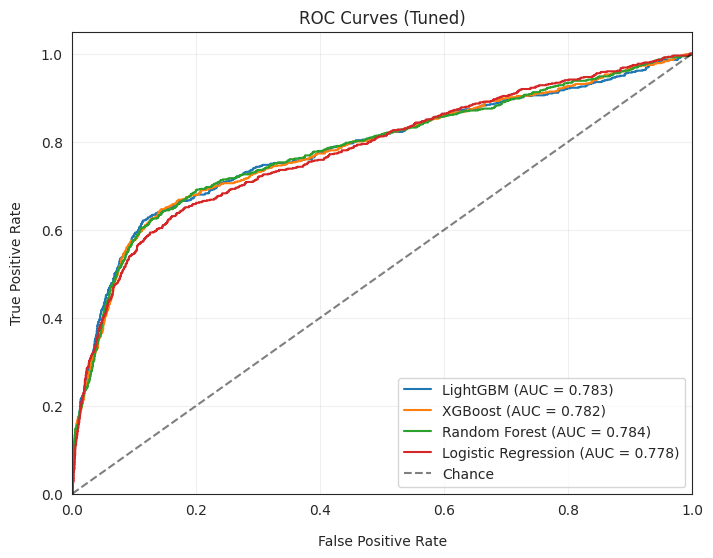

In [ ]:
plot_roc_curves(tuned_results, tag=' (Tuned)')

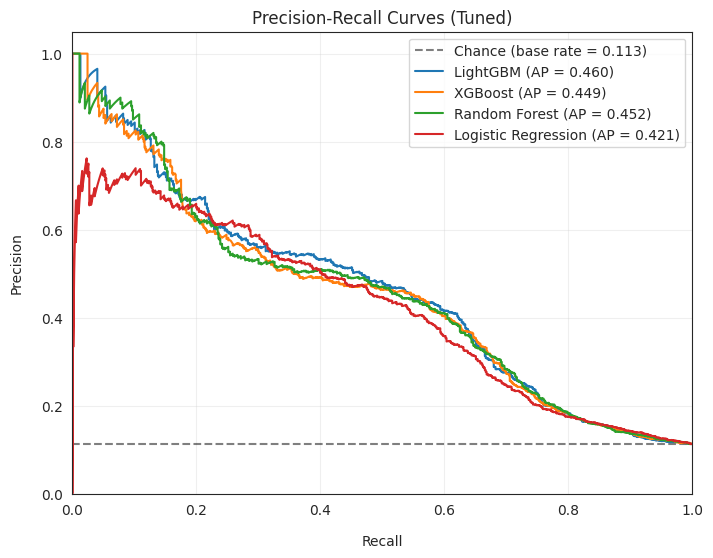

In [ ]:
plot_pr_curves(tuned_results, y_valid, tag=' (Tuned)')

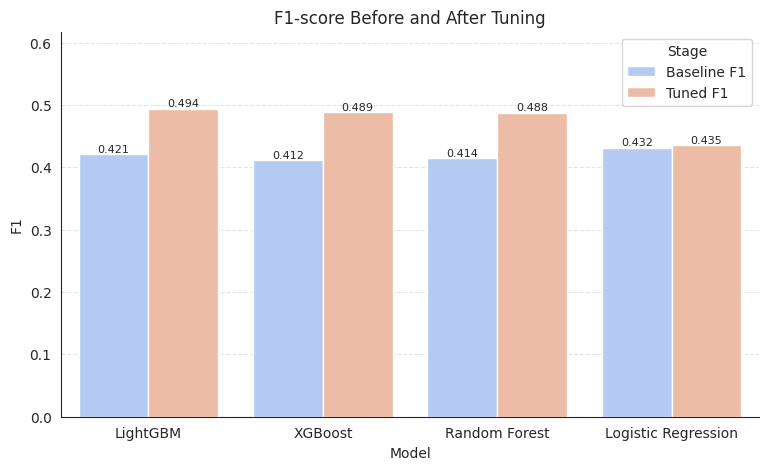

,Model,Baseline F1,Tuned F1
0,LightGBM,0.421,0.494
1,XGBoost,0.412,0.489
2,Random Forest,0.414,0.488
3,Logistic Regression,0.432,0.435


In [ ]:
# Baseline vs tuned F1, side by side
# Create a wide-format DataFrame comparing performance scores
compare = pd.DataFrame({
    'Model': [r['name'] for r in baseline_results.values()],
    'Baseline F1': [r['F1-score'] for r in baseline_results.values()],
    'Tuned F1': [tuned_results[k]['F1-score'] for k in baseline_results],
})

# Convert to long-format (melt) so Seaborn can group bars by 'Stage'
melted = compare.melt(id_vars='Model', var_name='Stage', value_name='F1')

fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
sns.barplot(data=melted, x='Model', y='F1', hue='Stage', palette='coolwarm', ax=ax)

# Automatically annotate each bar with its numerical value
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=8)

# Increase Y-limit to provide space for labels at the top of the bars
ax.set_ylim(0, max(melted['F1']) * 1.25)
ax.set_title('F1-score Before and After Tuning')
sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('f1_before_after_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

display(compare.round(3))

### 10.1 Is the difference between the models real?

The tuned models finish within a hundredth or two of each other on F1, which is small enough that the ranking could be an artefact of how the folds happened to be drawn. Each cross-validated score is the mean of `CV_FOLDS` fold scores, and the standard deviation of those folds puts a scale on that uncertainty.

The rule applied here is simple: if the gap between two models is smaller than their fold-to-fold variation, the notebook cannot claim one is genuinely better than the other, and the honest description is a tie with a point estimate rather than a winner.

.

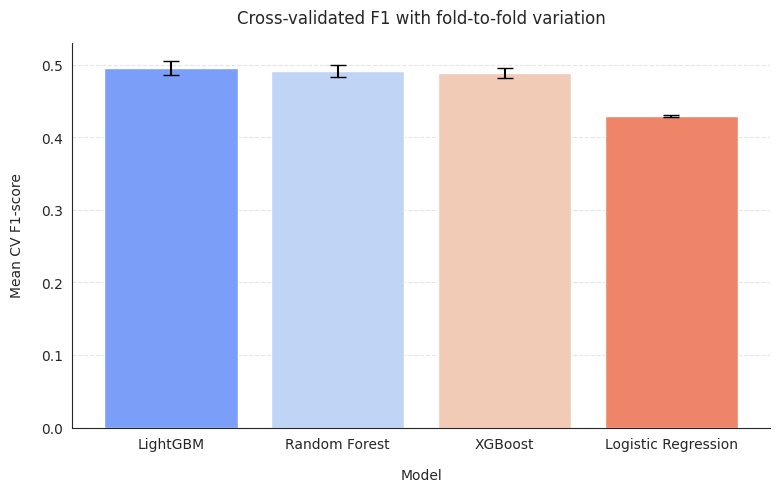

,name,mean_cv_f1,std_cv_f1,search_seconds
lgbm,LightGBM,0.4952,0.0099,333.1798
rfc,Random Forest,0.4907,0.0083,1149.9944
xgb,XGBoost,0.4883,0.0071,322.2920
lgr,Logistic Regression,0.4290,0.0016,910.7372


Top model:  LightGBM (0.4952 +/- 0.0099)
Runner-up:  Random Forest (0.4907 +/- 0.0083)
Gap between them:        0.0046
Larger of the two SDs:   0.0099

The gap is smaller than the fold-to-fold variation, so these two models are not distinguishable on this data. Report the leader as a point estimate, not as a demonstrated winner.


In [ ]:
cv_spread = pd.DataFrame(search_records).T
for col in ['mean_cv_f1', 'std_cv_f1', 'search_seconds']:
    cv_spread[col] = cv_spread[col].astype(float)
cv_spread = cv_spread.sort_values('mean_cv_f1', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
ax.bar(cv_spread['name'], cv_spread['mean_cv_f1'],
       yerr=cv_spread['std_cv_f1'], capsize=6,
       color=sns.color_palette('coolwarm', len(cv_spread)))
ax.set_title('Cross-validated F1 with fold-to-fold variation', pad=14)
ax.set_ylabel('Mean CV F1-score', labelpad=12)
ax.set_xlabel('Model', labelpad=12)
sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('cv_f1_variation.png', dpi=300, bbox_inches='tight')
plt.show()

display(cv_spread[['name', 'mean_cv_f1', 'std_cv_f1', 'search_seconds']].round(4))

# Compare the gap between the top two models against the measurement noise
top, second = cv_spread.iloc[0], cv_spread.iloc[1]
gap = top['mean_cv_f1'] - second['mean_cv_f1']
noise = max(top['std_cv_f1'], second['std_cv_f1'])

print(f"Top model:  {top['name']} ({top['mean_cv_f1']:.4f} +/- {top['std_cv_f1']:.4f})")
print(f"Runner-up:  {second['name']} ({second['mean_cv_f1']:.4f} +/- {second['std_cv_f1']:.4f})")
print(f"Gap between them:        {gap:.4f}")
print(f"Larger of the two SDs:   {noise:.4f}\n")

if gap < noise:
    print('The gap is smaller than the fold-to-fold variation, so these two models are '
          'not distinguishable on this data. Report the leader as a point estimate, '
          'not as a demonstrated winner.')
else:
    print('The gap exceeds the fold-to-fold variation, so the ranking of the top two '
          'models is supported by the cross-validation evidence.')

## 11. Final test set evaluation

The test set has been held out until now and is used exactly once, so these metrics are an honest estimate of performance on unseen clients. Using it more than once, for example to choose between models, would turn it into a second validation set and inflate the result.

Best model on validation F1: LightGBM



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


------------------------------------------------------------------------------------------
--> LightGBM (Test Set) <--
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      5481
           1       0.48      0.57      0.52       696

    accuracy                           0.88      6177
   macro avg       0.71      0.75      0.73      6177
weighted avg       0.89      0.88      0.89      6177



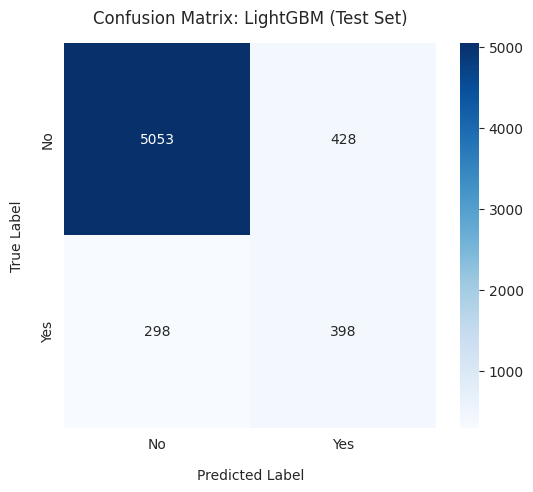

Test set F1:            0.5230
Test set ROC-AUC:       0.8108
Test set Avg Precision: 0.4821

Base subscription rate:       0.113
Precision on flagged clients: 0.482
Lift over untargeted calling: 4.3x


In [ ]:
best_abbr = max(tuned_results, key=lambda k: tuned_results[k]['F1-score'])
best_name = models[best_abbr]['name']
print(f'Best model on validation F1: {best_name}\n')

test_result = evaluate_model(
    best_pipelines[best_abbr], best_name, X_test, y_test, tag=' (Test Set)')

print(f"Test set F1:            {test_result['F1-score']:.4f}")
print(f"Test set ROC-AUC:       {test_result['ROC-AUC']:.4f}")
print(f"Test set Avg Precision: {test_result['Avg Precision']:.4f}")

# Practical framing: how much better than calling clients at random?
base_rate = y_test.mean()
lift = test_result['Precision'] / base_rate
print(f"\nBase subscription rate:       {base_rate:.3f}")
print(f"Precision on flagged clients: {test_result['Precision']:.3f}")
print(f"Lift over untargeted calling: {lift:.1f}x")

## 12. Feature importance

Tree models expose `feature_importances_`. Logistic regression uses absolute coefficient magnitudes on the scaled features, which ranks influence but hides direction; the sign of each coefficient tells me whether the feature pushes towards or away from subscription.

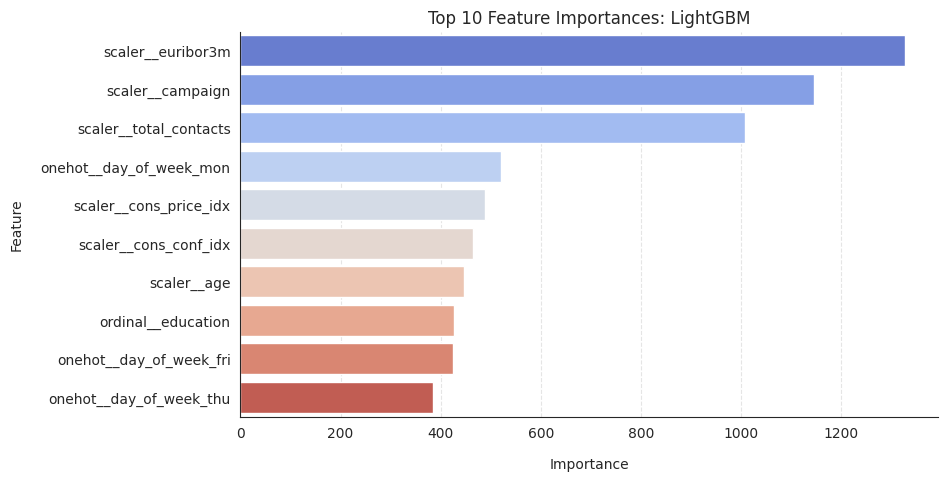

,feature,importance
0,scaler__euribor3m,1327
1,scaler__campaign,1146
2,scaler__total_contacts,1009
3,onehot__day_of_week_mon,521
4,scaler__cons_price_idx,489
5,scaler__cons_conf_idx,465
6,scaler__age,447
7,ordinal__education,426
8,onehot__day_of_week_fri,425
9,onehot__day_of_week_thu,385


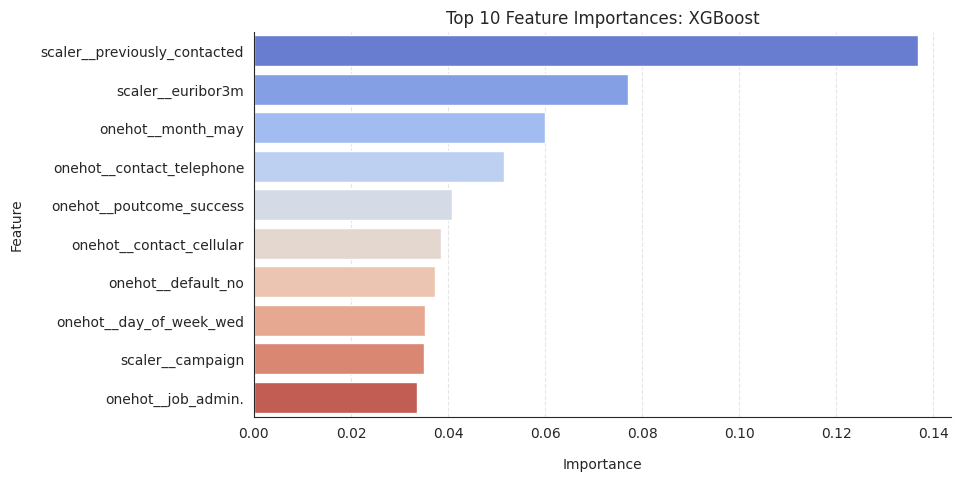

,feature,importance
0,scaler__previously_contacted,0.136885
1,scaler__euribor3m,0.077115
2,onehot__month_may,0.060043
3,onehot__contact_telephone,0.051477
4,onehot__poutcome_success,0.040874
5,onehot__contact_cellular,0.038622
6,onehot__default_no,0.037407
7,onehot__day_of_week_wed,0.035315
8,scaler__campaign,0.034975
9,onehot__job_admin.,0.033685


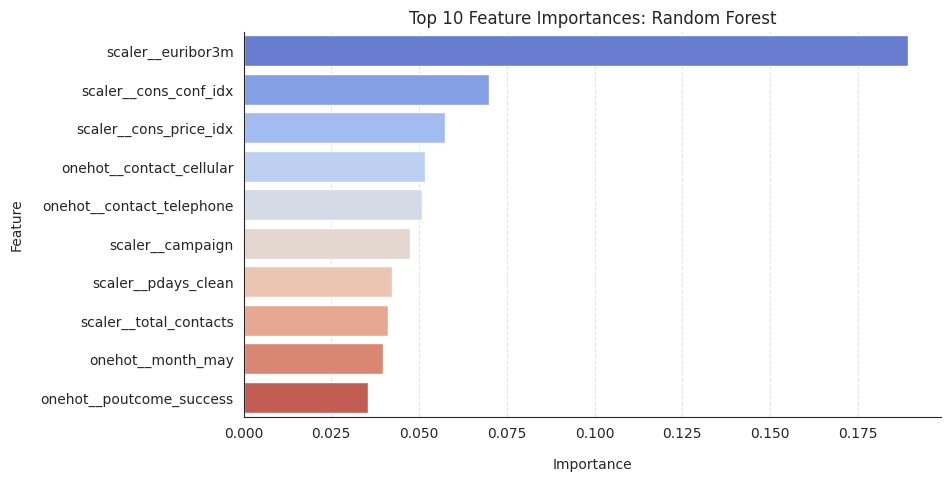

,feature,importance
0,scaler__euribor3m,0.189247
1,scaler__cons_conf_idx,0.069799
2,scaler__cons_price_idx,0.057440
3,onehot__contact_cellular,0.051604
4,onehot__contact_telephone,0.050866
5,scaler__campaign,0.047375
6,scaler__pdays_clean,0.042244
7,scaler__total_contacts,0.041247
8,onehot__month_may,0.039821
9,onehot__poutcome_success,0.035536


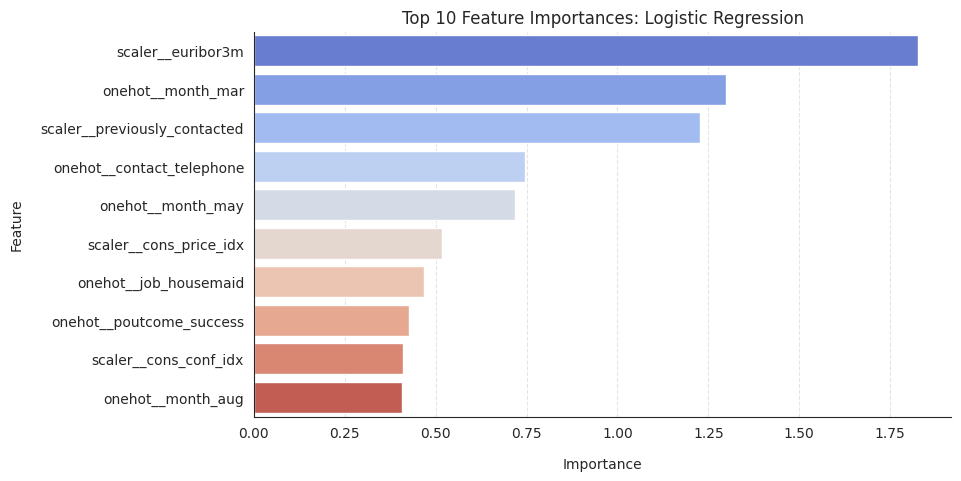

,feature,importance
0,scaler__euribor3m,1.827006
1,onehot__month_mar,1.297830
2,scaler__previously_contacted,1.227542
3,onehot__contact_telephone,0.746533
4,onehot__month_may,0.719381
5,scaler__cons_price_idx,0.517252
6,onehot__job_housemaid,0.467554
7,onehot__poutcome_success,0.426694
8,scaler__cons_conf_idx,0.409238
9,onehot__month_aug,0.406080


In [ ]:
def plot_feature_importance(fitted_pipeline, name, top_n=10):
    """Top-N importance chart for one tuned pipeline."""
    # 1. Extract the actual model and feature names from the fitted pipeline
    model = fitted_pipeline.named_steps['model']
    feature_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()

    # 2. Extract importance values based on model type
    if hasattr(model, 'feature_importances_'):
        # For tree-based models (Random Forest, XGBoost, LightGBM)
        importance = model.feature_importances_
    else:
        # For Logistic Regression, use absolute coefficient values as importance
        importance = np.abs(model.coef_.flatten())

    # 3. Create a DataFrame to rank and filter the top N features
    df_imp = (pd.DataFrame({'feature': feature_names, 'importance': importance})
                .sort_values('importance', ascending=False)
                .head(top_n))

    # 4. Visualize the results using a bar chart
    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    sns.barplot(data=df_imp, x='importance', y='feature', hue='feature',
                palette='coolwarm', legend=False, ax=ax)
    ax.set_title(f'Top {top_n} Feature Importances: {name}')
    ax.set_xlabel('Importance', labelpad=12)
    ax.set_ylabel('Feature', labelpad=12)
    sns.despine(top=True, right=True)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.savefig(f'importance_{name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    return df_imp

# Loop through all trained models to generate importance plots
for abbr, spec in models.items():
    imp_df = plot_feature_importance(best_pipelines[abbr], spec['name'])
    display(imp_df.reset_index(drop=True))

## 13. Summary of findings

Points to carry into the report:

- Optimising F1 moved the tree ensembles from high-precision, low-recall behaviour towards recall. Accuracy fell while F1 rose. On a dataset where roughly 89 percent of clients decline, this is the correct trade for the business problem and shows that accuracy would have been the wrong objective.
- The tuned models finish very close together. Section 10.1 sets the gap between the leading models against their fold-to-fold variation, and the ranking should be reported with that uncertainty rather than as a clean win.
- The Euribor rate dominates feature importance across all four models. A model that predicts subscription mainly from the economic climate describes Portugal in 2008 to 2010 and would need revalidation before use in another period or market.
- If `DROP_DURATION` is set to `False`, every metric jumps sharply. That jump is leakage, not skill.

Possible extensions: tuning the decision threshold against real call costs and deposit values rather than leaving it at 0.5; replacing SMOTE with the categorical-aware SMOTE-NC; bootstrapping test-set confidence intervals; and validating temporally with a rolling window, as in Moro et al. (2014), rather than a random split.